<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Modelo de regresión lineal para analizar la relación entre recursos sanitarios y datos sociodemográficos</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Descripción del problema

Se han recopilado datos sociodemográficos y de recursos sanitarios por condado en los Estados Unidos, y queremos averiguar si existe alguna relación entre los recursos de salud y los datos sociodemográficos.

Para ello, necesito definir una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# Paso 1: Cargar el CSV en un dataset de Python
El conjunto de datos se puede encontrar en la carpeta de este proyecto con el nombre demographic_health_data.csv. Puedes cargarlo directamente desde el enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=418&path=demographic_health_data.csv
O descargarlo y añadirlo manualmente en tu repositorio. En este dataset encontrarás un gran número de variables, que están definidas aquí.

# Paso 2: Realizar un EDA completo
Este segundo paso es fundamental para asegurarnos de que conservamos únicamente las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Usa el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir el conjunto de datos de forma adecuada en conjunto de entrenamiento y prueba, como hemos visto en lecciones anteriores.

# Paso 3: Construir un modelo de regresión lineal en Python
Comienza resolviendo el problema implementando un modelo de regresión lineal y analiza los resultados. Luego, usando los mismos datos y atributos por defecto, construye un modelo Lasso y compara los resultados con la regresión lineal base.

Analiza cómo evoluciona el R2 cuando cambia el hiperparámetro del modelo Lasso (puedes, por ejemplo, comenzar desde un valor de 0.0 hasta un valor de 20). Representa estos valores en un diagrama de líneas.

# Paso 4: Optimizar el modelo de regresión lineal anterior usando Python
Después de entrenar el modelo Lasso, si los resultados no son satisfactorios, optimízalo utilizando una de las técnicas vistas anteriormente.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Importar Librerías

</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Internal code
from analyze_qq_plot import plot_qq_with_analysis
from interpret_distribution_metrics import print_transformation_summary
from save_encoding_rules import save_encoding_rules

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, skew, kurtosis

# Scikit-learn - models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression

# Scikit-learn - metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# Scikit-learn - utilities
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# Paso 1: Cargar el CSV en un dataset de Python

Carga el dataset y especifica la variable objetivo

</div>

In [2]:
# Load your dataset
df = pd.read_csv('../data/raw/demographic_health_data.csv')
df.head()


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [4]:
df.dtypes

fips                        int64
TOT_POP                     int64
0-9                         int64
0-9 y/o % of total pop    float64
19-Oct                      int64
                           ...   
CKD_prevalence            float64
CKD_Lower 95% CI          float64
CKD_Upper 95% CI          float64
CKD_number                  int64
Urban_rural_code            int64
Length: 108, dtype: object

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Hay muchas variables relacionadas con la salud en el dataset, pero para este análisis nos centraremos en la variable "Health_Insurance_Coverage", que representa el porcentaje de personas en cada condado que tienen cobertura de seguro médico. Esta variable es un buen indicador del acceso a los recursos sanitarios y puede estar influenciada por diversos factores sociodemográficos.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Este dataset tiene 108 columnas (variables) con 3141 filas (condados). Todas las variables son numéricas. Parece que este dataset ha sido procesado y dividido/codificado/transformado en varias columnas a partir de columnas anteriores. Voy a intentar reducir el número de variables.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Primero, carguemos el dataset y examinemos su estructura y los tipos de variables que contiene.

</div>

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.0,18180.500000,29178.000000,45081.50000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.00000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.00000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.95184,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.25000,1.239139e+06
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.446242,0.568059,1.8,3.100000,3.400000,3.80000,6.200000e+00
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.50000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.10000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.25000,2.377660e+05


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de Valores Faltantes

</div>

In [6]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    display(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='barh', color='coral')
    plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")

✓ No missing values found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Detectar los duplicados

</div>

In [7]:
# Check for duplicate rows
print("="*70)
print("DUPLICATE ROWS DETECTION")
print("="*70)

# Count total duplicates
total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df)) * 100

print(f"\nTotal duplicate rows: {total_duplicates}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

if total_duplicates > 0:
    print(f"\n⚠ {total_duplicates} duplicate rows found!")
    
    # Show duplicate rows
    print("\nDuplicate rows:")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicates_df.head(20))  # Show first 20 duplicates
    
    # Option 1: Keep first occurrence
    print("\n📊 Options for handling duplicates:")
    print("   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')")
    print("   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')")
    print("   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)")
    
else:
    print("\n✓ No duplicate rows found in the dataset!")

#

DUPLICATE ROWS DETECTION

Total duplicate rows: 0
Percentage of duplicates: 0.00%

✓ No duplicate rows found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Encontrar Columnas Redundantes

#### 1. Columnas de Población Redundantes
| Acción | Columnas |
|--------|---------|
| Conservar | `TOT_POP` o `Total Population` (solo una) |
| Eliminar | `POP_ESTIMATE_2018` — duplicado |
| Conservar | Versión en porcentaje de mayores de 60 años |
| Eliminar | `Population Aged 60+` — conteo absoluto |

---

#### 2. Conservar Porcentajes, Eliminar Conteos Absolutos

**2.1 Grupos de Edad**
| Acción | Columnas |
|--------|---------|
| Eliminar | `0-9`, `10-19`, `20-29`, `30-39`, `40-49`, `50-59`, `60-69`, `70-79`, `80+` |
| Conservar | Todas las columnas `% of total pop` |

**2.2 Raza / Etnia**
| Acción | Columnas |
|--------|---------|
| Eliminar | `White-alone pop`, `Black-alone pop`, `Native American/American Indian-alone pop`, `Asian-alone pop`, `Hawaiian/Pacific Islander-alone pop`, `Two or more races pop` |
| Conservar | Todas las versiones en porcentaje `%` |

**2.3 Educación**
| Acción | Columnas |
|--------|---------|
| Eliminar | `Less than a high school diploma 2014-18`, `High school diploma only 2014-18`, `Some college or associate's degree 2014-18`, `Bachelor's degree or higher 2014-18` |
| Conservar | Todas las columnas `Percent of adults...` |

**2.4 Empleo**
| Acción | Columnas |
|--------|---------|
| Eliminar | `Civilian_labor_force_2018`, `Employed_2018`, `Unemployed_2018` |
| Conservar | `Unemployment_rate_2018` |

**2.5 Condiciones de Salud**
| Acción | Columnas |
|--------|---------|
| Eliminar | `anycondition_number`, `Obesity_number`, `Heart disease_number`, `COPD_number`, `diabetes_number`, `CKD_number` |
| Considerar eliminar | Todas las columnas `Lower 95% CI` y `Upper 95% CI` (12 en total) salvo que se realice análisis estadístico |

---

#### 3. Columnas de Atención Sanitaria con Baja Varianza
Estas columnas se **asumen idénticas a nivel estatal** — sin variación a nivel de condado:
- `Active Physicians per 100000 Population 2018 (AAMC)`
- `Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)`
- `Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)`
- `Active General Surgeons per 100000 Population 2018 (AAMC)`
- `Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)`

---

#### 4. Redundancia del Código FIPS
| Acción | Columnas |
|--------|---------|
| Eliminar | `STATE_FIPS`, `CNTY_FIPS` (componentes separados) |
| Conservar | `fips` (código FIPS de condado combinado) |

---

#### 5. Otras Redundancias
| Columna | Razón |
|--------|--------|
| `GQ_ESTIMATES_2018` | Población en Cuarteles Grupales — impacto generalmente pequeño |
| `MEDHHINC_2018` | Duplicado de `Median_Household_Income_2018` — eliminarlo |
| `CI90LBINC_2018` / `CI90UBINC_2018` | Intervalos de confianza del ingreso — eliminar salvo análisis estadístico |

</div>

In [8]:
df[['fips']].head()


,fips
0,1001
1,1003
2,1005
3,1007
4,1009


In [9]:
# Check the number of unique values in the 'fips' column
df['fips'].value_counts()

fips
1001     1
39091    1
39095    1
39097    1
39099    1
        ..
21115    1
21117    1
21119    1
21121    1
56045    1
Name: count, Length: 3140, dtype: int64

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Fips es un identificador único para cada condado, por lo que no debe eliminarse. Sin embargo, puede ser útil conservarlo como columna de índice o de referencia en el dataset, aunque no debe usarse como variable predictora en el modelo ya que no aporta información significativa para la predicción.

</div>

In [10]:
df[['TOT_POP', 'POP_ESTIMATE_2018']].head()
print((df['TOT_POP'] == df['POP_ESTIMATE_2018']).all())

True


In [11]:
# Drop redundant and unnecessary columns
print(f"Original shape: {df.shape}")
print(f"Original columns: {len(df.columns)}\n")

# Define columns to drop by category
columns_to_drop = []

# 1. Redundant Population Columns (keep only one)
redundant_pop = [
    'POP_ESTIMATE_2018',  # Keep TOT_POP or Total Population instead
    'Population Aged 60+'  # Already have percentage version
]
columns_to_drop.extend(redundant_pop)

# 2. Age Groups 
age_raw_counts = ['0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

columns_to_drop.extend(age_raw_counts)  

# 3. Race - Drop raw counts, keep percentages
race_raw_counts = [
    'White-alone pop',
    'Black-alone pop',
    'Native American/American Indian-alone pop',
    'Asian-alone pop',
    'Hawaiian/Pacific Islander-alone pop',
    'Two or more races pop'
]
columns_to_drop.extend(race_raw_counts)

# 4. Education - Drop raw counts, keep percentages
education_raw_counts = [
    'Less than a high school diploma 2014-18',
    'High school diploma only 2014-18',
    "Some college or associate's degree 2014-18",
    "Bachelor's degree or higher 2014-18"
]
columns_to_drop.extend(education_raw_counts)

# 5. Employment - Drop raw counts, keep unemployment rate
employment_raw_counts = [
    'Civilian_labor_force_2018',
    'Employed_2018',
    'Unemployed_2018'
]
columns_to_drop.extend(employment_raw_counts)

# 6. Health Conditions - Drop raw counts
health_raw_counts = [
    'anycondition_number',
    'Obesity_number',
    'Heart disease_number',
    'COPD_number',
    'diabetes_number',
    'CKD_number'
]
columns_to_drop.extend(health_raw_counts)

# 7. Health Conditions - Drop confidence intervals (unless doing statistical analysis)
health_ci_cols = [
    'anycondition_Lower 95% CI',
    'anycondition_Upper 95% CI',
    'Obesity_Lower 95% CI',
    'Obesity_Upper 95% CI',
    'Heart disease_Lower 95% CI',
    'Heart disease_Upper 95% CI',
    'COPD_Lower 95% CI',
    'COPD_Upper 95% CI',
    'diabetes_Lower 95% CI',
    'diabetes_Upper 95% CI',
    'CKD_Lower 95% CI',
    'CKD_Upper 95% CI'
]
columns_to_drop.extend(health_ci_cols)

# 8. Low Variance Healthcare Columns (assumed identical to state)
low_variance_healthcare = [
    'Active Physicians per 100000 Population 2018 (AAMC)',
    'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
    'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
    'Active General Surgeons per 100000 Population 2018 (AAMC)',
    'Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)'
]
columns_to_drop.extend(low_variance_healthcare)

# 9. FIPS Code Redundancy (keep only combined fips)
fips_redundant = [
    'STATE_FIPS',
    'CNTY_FIPS'
]
columns_to_drop.extend(fips_redundant)

# 10. Other redundant columns
other_redundant = [
    'GQ_ESTIMATES_2018',  # Group Quarters population
    'MEDHHINC_2018',  # Duplicate of Median_Household_Income_2018
    'CI90LBINC_2018',  # Income confidence interval lower bound
    'CI90UBINC_2018'   # Income confidence interval upper bound
]
columns_to_drop.extend(other_redundant)

# Check which columns exist in the dataframe
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
missing_columns = [col for col in columns_to_drop if col not in df.columns]

# Drop the columns
df_clean = df.drop(columns=existing_columns_to_drop)

# Summary
print(f"Successfully dropped {len(existing_columns_to_drop)} columns")
print(f"New shape: {df_clean.shape}")
print(f"Remaining columns: {len(df_clean.columns)}\n")

if missing_columns:
    print(f" Warning: {len(missing_columns)} columns not found in dataframe:")
    for col in missing_columns:
        print(f"  - {col}")
    print()

print("Dropped columns by category:")
print(f"  - Redundant population: {len([c for c in redundant_pop if c in existing_columns_to_drop])}")
print(f"  - Age raw counts: {len([c for c in age_raw_counts if c in existing_columns_to_drop])}")
print(f"  - Race raw counts: {len([c for c in race_raw_counts if c in existing_columns_to_drop])}")
print(f"  - Education raw counts: {len([c for c in education_raw_counts if c in existing_columns_to_drop])}")
print(f"  - Employment raw counts: {len([c for c in employment_raw_counts if c in existing_columns_to_drop])}")
print(f"  - Health raw counts: {len([c for c in health_raw_counts if c in existing_columns_to_drop])}")
print(f"  - Health confidence intervals: {len([c for c in health_ci_cols if c in existing_columns_to_drop])}")
print(f"  - Low variance healthcare: {len([c for c in low_variance_healthcare if c in existing_columns_to_drop])}")
print(f"  - FIPS redundancy: {len([c for c in fips_redundant if c in existing_columns_to_drop])}")
print(f"  - Other redundant: {len([c for c in other_redundant if c in existing_columns_to_drop])}")


Original shape: (3140, 108)
Original columns: 108

Successfully dropped 53 columns
New shape: (3140, 55)
Remaining columns: 55

Dropped columns by category:
  - Redundant population: 2
  - Age raw counts: 9
  - Race raw counts: 6
  - Education raw counts: 4
  - Employment raw counts: 3
  - Health raw counts: 6
  - Health confidence intervals: 12
  - Low variance healthcare: 5
  - FIPS redundancy: 2
  - Other redundant: 4


In [12]:
df_clean.head()


,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,N_POP_CHG_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Primary Care Physicians per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,158,11.8,9.6,2.2,0.0,0.7,0.6,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,3.6,59338,119.0,77.2,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Autauga,Alabama,42438,47.6,35.8,7.9,8.6,12.9,3.1,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,5403,10.5,10.3,0.1,0.5,24.3,24.8,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,3.6,57588,115.5,77.2,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Baldwin,Alabama,170912,40.2,29.7,7.8,8.6,12.0,3.2,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,-277,10.4,12.9,-2.5,0.5,-9.1,-8.6,27.0,35.7,25.1,12.2,6788,30.9,43.9,36.7,5.2,34382,68.9,77.2,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Barbour,Alabama,19689,57.5,40.7,11.0,12.1,19.7,4.5,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,-155,11.1,11.4,-0.3,0.4,-7.0,-6.6,16.8,47.3,24.4,11.5,4400,21.8,27.8,26.3,4.0,46064,92.3,77.2,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,0,22580,21.1,Bibb,Alabama,17813,51.6,38.7,8.6,10.0,14.1,3.3,2
4,1009,57840,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,4.036999,95.878285,1.642462,0.653527,0.319848,0.121024,1.384855,13,11.8,11.4,0.3,0.1,-0.2,0.0,19.8,34.0,33.5,12.6,7527,13.2,18.0,15.5,3.5,50412,101.1,77.2,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,6,57667,23.6,Blount,Alabama,44448,46.3,34.0,9.2,10.5,13.5,3.4,2


In [13]:
df_clean.shape

(3140, 55)

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Aún tenemos 55 columnas.

</div>

In [14]:
df_clean.columns

Index(['fips', 'TOT_POP', '0-9 y/o % of total pop', '10-19 y/o % of total pop',
       '20-29 y/o % of total pop', '30-39 y/o % of total pop',
       '40-49 y/o % of total pop', '50-59 y/o % of total pop',
       '60-69 y/o % of total pop', '70-79 y/o % of total pop',
       '80+ y/o % of total pop', '% White-alone', '% Black-alone',
       '% NA/AI-alone', '% Asian-alone', '% Hawaiian/PI-alone',
       '% Two or more races', 'N_POP_CHG_2018', 'R_birth_2018', 'R_death_2018',
       'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018',
       'R_NET_MIG_2018',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'POVALL_2018', 'PCTPOVALL_2018', 'PCTPOV017_2018', 'PCTPOV517_2018',
       'Unemployment_rate_2018', 'Median_Hous

In [15]:
# Check for age-related columns in the dataframe
print("Age-related columns in dataframe:")
print("="*60)

# Check for specific age patterns
age_patterns = ['0-9 y/o % of total pop', '10-19 y/o % of total pop',
       '20-29 y/o % of total pop', '30-39 y/o % of total pop',
       '40-49 y/o % of total pop', '50-59 y/o % of total pop',
       '60-69 y/o % of total pop', '70-79 y/o % of total pop',
       '80+ y/o % of total pop']
age_cols = [col for col in df.columns if any(pattern in col.lower() for pattern in age_patterns)]

if age_cols:
    print(f"\nFound {len(age_cols)} age-related columns:")
    for col in age_cols:
        print(f"  • {col}")
else:
    print("No age-related columns found")

Age-related columns in dataframe:

Found 9 age-related columns:
  • 0-9 y/o % of total pop
  • 10-19 y/o % of total pop
  • 20-29 y/o % of total pop
  • 30-39 y/o % of total pop
  • 40-49 y/o % of total pop
  • 50-59 y/o % of total pop
  • 60-69 y/o % of total pop
  • 70-79 y/o % of total pop
  • 80+ y/o % of total pop


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### ¿Por qué consolidar las columnas de edad?

**Problema:** El dataset tiene ~18 columnas de edad detalladas (9 conteos + 9 porcentajes), lo cual:
- Genera alta dimensionalidad
- Causa multicolinealidad (los grupos de edad adyacentes están altamente correlacionados)
- Dificulta la interpretación del modelo

**Solución:** Agrupar en 3 etapas de vida significativas:
- **Jóvenes (0-29)**: Infancia, educación, inicio de carrera
- **Adultos (30-59)**: Años de mayor actividad laboral, formación familiar
- **Mayores (60+)**: Jubilación, mayores necesidades de atención médica

**Beneficios:**
- Reduce la dimensionalidad de 18 → 3 columnas
- Captura tendencias por edad sin multicolinealidad
- Coeficientes más interpretables en el modelo
- Se alinea con los patrones típicos del análisis demográfico

</div>

In [16]:
# Consolidate age columns into 3 categories
# Young: 0-29 years (education, early career)
# Adult: 30-59 years (peak working years)
# Seniot: 60+ years 

# Create the consolidated columns by summing percentages
df_clean['young_0_29'] = 0.0
if '0-9 y/o % of total pop' in df_clean.columns:
    df_clean['young_0_29'] += df_clean['0-9 y/o % of total pop']
if '10-19 y/o % of total pop' in df_clean.columns:
    df_clean['young_0_29'] += df_clean['10-19 y/o % of total pop']
if '20-29 y/o % of total pop' in df_clean.columns:
    df_clean['young_0_29'] += df_clean['20-29 y/o % of total pop']

df_clean['adult_30_59'] = 0.0
if '30-39 y/o % of total pop' in df_clean.columns:
    df_clean['adult_30_59'] += df_clean['30-39 y/o % of total pop']
if '40-49 y/o % of total pop' in df_clean.columns:
    df_clean['adult_30_59'] += df_clean['40-49 y/o % of total pop']
if '50-59 y/o % of total pop' in df_clean.columns:
    df_clean['adult_30_59'] += df_clean['50-59 y/o % of total pop']

df_clean['senior_60_plus'] = 0.0
if '60-69 y/o % of total pop' in df_clean.columns:
    df_clean['senior_60_plus'] += df_clean['60-69 y/o % of total pop']
if '70-79 y/o % of total pop' in df_clean.columns:
    df_clean['senior_60_plus'] += df_clean['70-79 y/o % of total pop']
if '80+ y/o % of total pop' in df_clean.columns:
    df_clean['senior_60_plus'] += df_clean['80+ y/o % of total pop']

print("Created consolidated age columns:")
print(f"  - young_0_29: {df_clean['young_0_29'].mean():.2f}% (avg)")
print(f"  - adult_30_59: {df_clean['adult_30_59'].mean():.2f}% (avg)")
print(f"  - senior_60_plus: {df_clean['senior_60_plus'].mean():.2f}% (avg)")

# Drop the original individual age percentage columns
age_cols_to_drop = [
    '0-9 y/o % of total pop', '10-19 y/o % of total pop', '20-29 y/o % of total pop',
    '30-39 y/o % of total pop', '40-49 y/o % of total pop', '50-59 y/o % of total pop',
    '60-69 y/o % of total pop', '70-79 y/o % of total pop', '80+ y/o % of total pop'
]

existing_to_drop = [col for col in age_cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_to_drop)

print(f"\nDropped {len(existing_to_drop)} individual age columns")
print(f"Reduced from 9 age columns → 3 consolidated columns")

Created consolidated age columns:
  - young_0_29: 36.85% (avg)
  - adult_30_59: 36.83% (avg)
  - senior_60_plus: 26.32% (avg)

Dropped 9 individual age columns
Reduced from 9 age columns → 3 consolidated columns


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Consolidar columnas sobre raza - ¿Por qué consolidarlas?

Todas estas columnas están altamente correlacionadas y representan la misma información (composición racial de la población).
Podemos reducirlas todas a dos columnas: una para una sola raza y otra para diversity_race (que sería el porcentaje de la población que no es únicamente blanca).

Estas son las columnas relacionadas con la raza:
* % White-alone, % de la población que es únicamente blanca
* Black-alone pop
* % Black-alone
* Native American/American Indian-alone pop
* % NA/AI-alone
* Asian-alone pop
* % Asian-alone
* Hawaiian/Pacific Islander-alone pop
* % Hawaiian/PI-alone
* Two or more races pop
* % Two or more races

Pasos a seguir:

</div>

In [17]:
# ========================================
# RACE/ETHNICITY CONSOLIDATION (6 → 2 columns)
# ========================================
print("Consolidating Race/Ethnicity columns (6 → 2)...")
print(f"Shape before: {df_clean.shape}\n")

# First, drop all raw population counts (keep only percentages)
race_raw_counts = [
    'White-alone pop',
    'Black-alone pop',
    'Native American/American Indian-alone pop',
    'Asian-alone pop',
    'Hawaiian/Pacific Islander-alone pop',
    'Two or more races pop'
]

# Drop raw counts
existing_raw = [col for col in race_raw_counts if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_raw)
print(f"✓ Dropped {len(existing_raw)} raw population count columns\n")

# Now consolidate percentage columns into 2 meaningful metrics
race_pct_cols = [
    '% White-alone',
    '% Black-alone', 
    '% NA/AI-alone',
    '% Asian-alone',
    '% Hawaiian/PI-alone',
    '% Two or more races'
]

# Check which columns exist
existing_pct_cols = [col for col in race_pct_cols if col in df_clean.columns]

if existing_pct_cols:
    # 1. Create Racial Diversity Index (Simpson's Diversity Index)
    # Higher value = more diverse (0 = completely homogeneous, 1 = perfectly diverse)
    race_props = df_clean[existing_pct_cols].div(100)  # Convert to proportions
    df_clean['racial_diversity_index'] = 1 - (race_props ** 2).sum(axis=1)
    
    # 2. Create Minority Percentage (total non-white population)
    if '% White-alone' in df_clean.columns:
        df_clean['pct_minority'] = 100 - df_clean['% White-alone']
    else:
        # If White-alone doesn't exist, sum all minority percentages
        minority_cols = [col for col in existing_pct_cols if 'White' not in col]
        df_clean['pct_minority'] = df_clean[minority_cols].sum(axis=1)
    
    print("Created consolidated metrics:")
    print(f"   • racial_diversity_index: mean = {df_clean['racial_diversity_index'].mean():.3f}")
    print(f"     (0 = homogeneous, 1 = very diverse)")
    print(f"   • pct_minority: mean = {df_clean['pct_minority'].mean():.2f}%")
    print(f"     (% non-white population)\n")
    
    # Drop individual race percentage columns
    df_clean = df_clean.drop(columns=existing_pct_cols)
    print(f"✓ Dropped {len(existing_pct_cols)} individual race percentage columns")
    
else:
    print("No race percentage columns found in dataframe")

print(f"\nRace consolidation complete!")
print(f"   Reduced from {len(race_raw_counts) + len(race_pct_cols)} columns → 2 columns")
print(f"   New shape: {df_clean.shape}")

Consolidating Race/Ethnicity columns (6 → 2)...
Shape before: (3140, 49)

✓ Dropped 0 raw population count columns

Created consolidated metrics:
   • racial_diversity_index: mean = 0.221
     (0 = homogeneous, 1 = very diverse)
   • pct_minority: mean = 15.51%
     (% non-white population)

✓ Dropped 6 individual race percentage columns

Race consolidation complete!
   Reduced from 12 columns → 2 columns
   New shape: (3140, 45)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de Columnas de Población y Migración
Relaciones matemáticas:

* R_NATURAL_INC_2018 = R_birth_2018 - R_death_2018 (nacimientos menos defunciones)
* R_NET_MIG_2018 = R_INTERNATIONAL_MIG_2018 + R_DOMESTIC_MIG_2018 (migración total)

Cambio: 8 columnas → 3 columnas

Conservo estas 3 columnas:
* N_POP_CHG_2018 - Cambio numérico total de la población (útil para crecimiento/descenso absoluto)
* R_NATURAL_INC_2018 - Tasa de incremento natural (captura el balance nacimientos-defunciones)
* R_NET_MIG_2018 - Tasa de migración neta (captura los efectos totales de migración)

Elimino estas 5 columnas:
* GQ_ESTIMATES_2018 - Población en Cuarteles Grupales (institucional, generalmente de bajo impacto)
* R_birth_2018 - Redundante (capturada en R_NATURAL_INC_2018)
* R_death_2018 - Redundante (capturada en R_NATURAL_INC_2018)
* R_INTERNATIONAL_MIG_2018 - Redundante (capturada en R_NET_MIG_2018)
* R_DOMESTIC_MIG_2018 - Redundante (capturada en R_NET_MIG_2018)

</div>

In [18]:
# ========================================
# POPULATION CHANGE & MIGRATION CONSOLIDATION (8 → 3 columns)
# ========================================
print("Consolidating Population Change & Migration columns (8 → 3)...")
print(f"Shape before: {df_clean.shape}\n")

# Define columns to drop
migration_cols_to_drop = [
    'GQ_ESTIMATES_2018',           # Group Quarters (low impact)
    'R_birth_2018',                # Captured in R_NATURAL_INC_2018
    'R_death_2018',                # Captured in R_NATURAL_INC_2018
    'R_INTERNATIONAL_MIG_2018',    # Captured in R_NET_MIG_2018
    'R_DOMESTIC_MIG_2018'          # Captured in R_NET_MIG_2018
]

# Check which columns exist
existing_to_drop = [col for col in migration_cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_to_drop)

print(f"Dropped {len(existing_to_drop)} redundant columns:")
for col in existing_to_drop:
    print(f"   • {col}")

print(f"\nKept 3 informative columns:")
print(f"   • N_POP_CHG_2018 (population change)")
print(f"   • R_NATURAL_INC_2018 (birth-death balance)")
print(f"   • R_NET_MIG_2018 (total migration)")

print(f"\nReduced from 8 columns → 3 columns")
print(f"New shape: {df_clean.shape}")

Consolidating Population Change & Migration columns (8 → 3)...
Shape before: (3140, 45)

Dropped 4 redundant columns:
   • R_birth_2018
   • R_death_2018
   • R_INTERNATIONAL_MIG_2018
   • R_DOMESTIC_MIG_2018

Kept 3 informative columns:
   • N_POP_CHG_2018 (population change)
   • R_NATURAL_INC_2018 (birth-death balance)
   • R_NET_MIG_2018 (total migration)

Reduced from 8 columns → 3 columns
New shape: (3140, 41)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de Columnas de Educación
Estado actual: 8 columnas
* Less than a high school diploma 2014-18
* High school diploma only 2014-18
* Some college or associate's degree 2014-18
* Bachelor's degree or higher 2014-18
* Percent of adults with less than a high school diploma 2014-18
* Percent of adults with a high school diploma only 2014-18
* Percent of adults completing some college or associate's degree 2014-18
* Percent of adults with a bachelor's degree or higher 2014-18

4 conteos absolutos de población
4 columnas en porcentaje

Cambio: 8 columnas → 2 columnas

Estrategia:
Eliminar todos los conteos absolutos (conservar solo los porcentajes — están normalizados)
Agrupar en 2 categorías amplias de educación:
- Baja Educación = Sin diploma de secundaria + Solo diploma de secundaria
- Alta Educación = Algo de universidad o asociado + Licenciatura o superior

</div>

In [19]:
# ========================================
# EDUCATION CONSOLIDATION (8 → 2 columns)
# ========================================
print(" Consolidating Education columns (8 → 2)...")
print(f"Shape before: {df_clean.shape}\n")

# Step 1: Drop raw population counts (keep only percentages)
education_raw_counts = [
    'Less than a high school diploma 2014-18',
    'High school diploma only 2014-18',
    "Some college or associate's degree 2014-18",
    "Bachelor's degree or higher 2014-18"
]

existing_raw = [col for col in education_raw_counts if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_raw)
print(f"Dropped {len(existing_raw)} raw count columns\n")

# Step 2: Create consolidated percentage categories
# Low Education = Less than HS + HS diploma only
if 'Percent of adults with less than a high school diploma 2014-18' in df_clean.columns:
    df_clean['pct_low_education'] = (
        df_clean['Percent of adults with less than a high school diploma 2014-18'] + 
        df_clean['Percent of adults with a high school diploma only 2014-18']
    )

# High Education = Some college + Bachelor's or higher
if "Percent of adults completing some college or associate's degree 2014-18" in df_clean.columns:
    df_clean['pct_high_education'] = (
        df_clean["Percent of adults completing some college or associate's degree 2014-18"] +
        df_clean["Percent of adults with a bachelor's degree or higher 2014-18"]
    )

print("Created consolidated education categories:")
print(f"   • pct_low_education: mean = {df_clean['pct_low_education'].mean():.2f}%")
print(f"     (< HS + HS diploma only)")
print(f"   • pct_high_education: mean = {df_clean['pct_high_education'].mean():.2f}%")
print(f"     (Some college + Bachelor's+)\n")

# Step 3: Drop individual percentage columns
education_pct_cols = [
    'Percent of adults with less than a high school diploma 2014-18',
    'Percent of adults with a high school diploma only 2014-18',
    "Percent of adults completing some college or associate's degree 2014-18",
    "Percent of adults with a bachelor's degree or higher 2014-18"
]

existing_pct = [col for col in education_pct_cols if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_pct)
print(f"✓ Dropped {len(existing_pct)} individual percentage columns")

print(f"\nReduced from 8 education columns → 2 columns")
print(f"New shape: {df_clean.shape}")

 Consolidating Education columns (8 → 2)...
Shape before: (3140, 41)

Dropped 0 raw count columns

Created consolidated education categories:
   • pct_low_education: mean = 47.70%
     (< HS + HS diploma only)
   • pct_high_education: mean = 52.30%
     (Some college + Bachelor's+)

✓ Dropped 4 individual percentage columns

Reduced from 8 education columns → 2 columns
New shape: (3140, 39)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis: Columnas de Pobreza, Ingresos y Empleo

#### Actual: 11 columnas → Objetivo: 3 columnas

| Columna | Descripción |
|--------|-------------|
| `POVALL_2018` | Estimación de personas de todas las edades en pobreza 2018 |
| `PCTPOVALL_2018` | Porcentaje estimado de personas de todas las edades en pobreza 2018 |
| `PCTPOV017_2018` | Porcentaje estimado de personas de 0 a 17 años en pobreza 2018 |
| `PCTPOV517_2018` | Estimación de niños de 5 a 17 años en familias en pobreza 2018 |
| `MEDHHINC_2018` | Estimación de la mediana del ingreso familiar 2018 |
| `CI90LBINC_2018` | Límite inferior del IC al 90% de la mediana del ingreso familiar 2018 |
| `CI90UBINC_2018` | Límite superior del IC al 90% de la mediana del ingreso familiar 2018 |
| `Civilian_labor_force_2018` | Promedio anual de la fuerza laboral civil |
| `Employed_2018` | Número de empleados promedio anual |
| `Unemployed_2018` | Número de desempleados promedio anual |
| `Unemployment_rate_2018` | Tasa de desempleo (%) |

---

#### Pasos a seguir

**1. Pobreza (4 → 1 columna)**

| Acción | Columna | Razón |
|--------|--------|--------|
| Conservar | `PCTPOVALL_2018` | % de personas en pobreza |
| Eliminar | `POVALL_2018` | Conteo absoluto — redundante con el porcentaje |
| Eliminar | `PCTPOV017_2018` | Pobreza infantil 0-17 — altamente correlacionada con el total |
| Eliminar | `PCTPOV517_2018` | Pobreza infantil 5-17 — altamente correlacionada con el total |

**2. Ingresos (3 → 1 columna)**

| Acción | Columna | Razón |
|--------|--------|--------|
| Conservar | `Median_Household_Income_2018` | Mediana del ingreso familiar |
| Eliminar | `CI90LBINC_2018` | Límite inferior del intervalo de confianza — no necesario para modelado |
| Eliminar | `CI90UBINC_2018` | Límite superior del intervalo de confianza — no necesario para modelado |

**3. Empleo (4 → 1 columna)**

| Acción | Columna | Razón |
|--------|--------|--------|
| Conservar | `Unemployment_rate_2018` | Tasa normalizada — captura el panorama completo del empleo |
| Eliminar | `Civilian_labor_force_2018` | Conteo absoluto — proxy del tamaño de la población |
| Eliminar | `Employed_2018` | Conteo absoluto — proxy del tamaño de la población |
| Eliminar | `Unemployed_2018` | Conteo absoluto — capturado por la tasa |

> La tasa narra la historia; los conteos absolutos son solo proxies del tamaño de la población.

</div>

In [20]:
# ========================================
# POVERTY, INCOME & EMPLOYMENT CONSOLIDATION (11 → 3 columns)
# ========================================
print("Consolidating Poverty, Income & Employment columns (11 → 3)...")
print(f"Shape before: {df_clean.shape}\n")

# Define columns to drop
socioeconomic_to_drop = [
    # Poverty - keep only overall percentage
    'POVALL_2018',           # Raw count (redundant)
    'PCTPOV017_2018',        # Child poverty 0-17 (correlated)
    'PCTPOV517_2018',        # Child poverty 5-17 (correlated)
    
    # Income - keep only median, drop confidence intervals
    'CI90LBINC_2018',        # Income CI lower bound
    'CI90UBINC_2018',        # Income CI upper bound
    
    # Employment - keep only unemployment rate
    'Civilian_labor_force_2018',  # Raw count
    'Employed_2018',              # Raw count
    'Unemployed_2018'             # Raw count
]

# Check which columns exist and drop them
existing_to_drop = [col for col in socioeconomic_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_to_drop)

# Standardize income column naming for consistency
if 'MEDHHINC_2018' in df_clean.columns and 'Median_Household_Income_2018' not in df_clean.columns:
    df_clean = df_clean.rename(columns={'MEDHHINC_2018': 'Median_Household_Income_2018'})
elif 'MEDHHINC_2018' in df_clean.columns and 'Median_Household_Income_2018' in df_clean.columns:
    df_clean = df_clean.drop(columns=['MEDHHINC_2018'])

print(f"Dropped {len(existing_to_drop)} columns:")
for col in existing_to_drop:
    print(f"   • {col}")

print(f"\nKept 3 key socioeconomic indicators:")
if 'PCTPOVALL_2018' in df_clean.columns:
    print(f"   • PCTPOVALL_2018 (poverty rate)")
if 'Median_Household_Income_2018' in df_clean.columns:
    print(f"   • Median_Household_Income_2018 (median income)")
if 'Unemployment_rate_2018' in df_clean.columns:
    print(f"   • Unemployment_rate_2018 (unemployment %)")

print(f"\nReduced from 11 columns → 3 columns")
print(f"New shape: {df_clean.shape}")

Consolidating Poverty, Income & Employment columns (11 → 3)...
Shape before: (3140, 39)

Dropped 3 columns:
   • POVALL_2018
   • PCTPOV017_2018
   • PCTPOV517_2018

Kept 3 key socioeconomic indicators:
   • PCTPOVALL_2018 (poverty rate)
   • Median_Household_Income_2018 (median income)
   • Unemployment_rate_2018 (unemployment %)

Reduced from 11 columns → 3 columns
New shape: (3140, 36)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis: Columnas de Ingresos y Atención Médica

Actual: 13 columnas

Problema clave: La mayoría de estas columnas tienen un valor predictivo muy bajo:

Las columnas de atención médica "por cada 100.000" están "asumidas como idénticas al nivel estatal" = SIN variación a nivel de condado ❌
Los conteos absolutos (enfermeras, hospitales, etc.) son solo proxies de la población = altamente correlacionados con TOT_POP ❌

Recomendación: 13 columnas → 1 columna (o eliminar todas)

Pasos a seguir:
1. Ingresos (1 → 0 columnas - ELIMINAR)
* Eliminar: Med_HH_Income_Percent_of_State_Total_2018
* Razón: Redundante con Median_Household_Income_2018 (ingreso absoluto)
* El porcentaje y el valor absoluto aportan la misma información

2. Atención Médica - Baja Varianza (5 → 0 columnas - ELIMINAR TODAS)
* Estas son idénticas en todos los condados de un estado:
  * Active Physicians per 100000 Population 2018 (AAMC)
  * Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)
  * Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)
  * Active General Surgeons per 100000 Population 2018 (AAMC)
  * Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)
* Razón: Varianza cero dentro de los estados = inútil para predicción

3. Atención Médica - Conteos Absolutos (7 → 1 columna)
Estos son proxies de la población (altamente correlacionados con TOT_POP):

* Conservar UNA: Active Primary Care Physicians per 100000 Population 2018 (AAMC) (si tiene varianza)
* Eliminar el resto (enfermeras, hospitales, especialistas, camas de UCI)
O mejor: Eliminar todas las 7 ya que son proporcionales a la población

</div>

In [21]:
# ========================================
# INCOME & HEALTHCARE CLEANUP (13 → 1 or 0 columns)
# ========================================
print("Cleaning Income & Healthcare columns (13 → 1)...")
print(f"Shape before: {df_clean.shape}\n")

# Define columns to drop
healthcare_income_to_drop = [
    # Income duplicate
    'Med_HH_Income_Percent_of_State_Total_2018',  # Redundant with Median_Household_Income_2018
    
    # Healthcare - Low variance (identical to state)
    'Active Physicians per 100000 Population 2018 (AAMC)',
    'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
    'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
    'Active General Surgeons per 100000 Population 2018 (AAMC)',
    'Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)',
    
    # Healthcare - Raw counts (population proxies)
    'Total nurse practitioners (2019)',
    'Total physician assistants (2019)',
    'Total Hospitals (2019)',
    'Internal Medicine Primary Care (2019)',
    'Family Medicine/General Practice Primary Care (2019)',
    'Total Specialist Physicians (2019)',
    'ICU Beds_x'
]

# Check which columns exist and drop them
existing_to_drop = [col for col in healthcare_income_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_to_drop)

print(f"Dropped {len(existing_to_drop)} columns:")
print("\nLow variance (identical to state): 5 columns")
print("   • Active Physicians per 100000...")
print("   • Total Active Patient Care Physicians...")
print("   • (etc.)")

print("\nPopulation proxies (raw counts): 7 columns")
print("   • Total nurse practitioners")
print("   • Total physician assistants")
print("   • Total Hospitals")
print("   • (etc.)")

print("\nIncome duplicate: 1 column")
print("   • Med_HH_Income_Percent_of_State_Total_2018")

print(f"\nReduced from 13 columns → 0 columns")
print(f"   (All were redundant or low-variance)")
print(f"New shape: {df_clean.shape}")


Cleaning Income & Healthcare columns (13 → 1)...
Shape before: (3140, 36)

Dropped 8 columns:

Low variance (identical to state): 5 columns
   • Active Physicians per 100000...
   • Total Active Patient Care Physicians...
   • (etc.)

Population proxies (raw counts): 7 columns
   • Total nurse practitioners
   • Total physician assistants
   • Total Hospitals
   • (etc.)

Income duplicate: 1 column
   • Med_HH_Income_Percent_of_State_Total_2018

Reduced from 13 columns → 0 columns
   (All were redundant or low-variance)
New shape: (3140, 28)


In [22]:
df_clean.columns

Index(['fips', 'TOT_POP', 'N_POP_CHG_2018', 'R_NATURAL_INC_2018',
       'R_NET_MIG_2018', 'PCTPOVALL_2018', 'Unemployment_rate_2018',
       'Median_Household_Income_2018',
       'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Total Population', 'Percent of Population Aged 60+', 'COUNTY_NAME',
       'STATE_NAME', 'county_pop2018_18 and older', 'anycondition_prevalence',
       'Obesity_prevalence', 'Heart disease_prevalence', 'COPD_prevalence',
       'diabetes_prevalence', 'CKD_prevalence', 'Urban_rural_code',
       'young_0_29', 'adult_30_59', 'senior_60_plus', 'racial_diversity_index',
       'pct_minority', 'pct_low_education', 'pct_high_education'],
      dtype='object')

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de las Columnas Restantes

#### Actual: 13 columnas → Objetivo: 6 columnas

| # | Acción | Columnas | Razón |
|---|--------|---------|--------|
| 1 | **Eliminar** | `Total Population`, `county_pop2018_18 and older` | Duplicados de `TOT_POP` |
| 2 | **Eliminar** | `COUNTY_NAME`, `STATE_NAME` | Campos de texto — usar `fips` en su lugar |
| 3 | **Eliminar** | `Percent of Population Aged 60+` | Duplicado de `senior_60_plus` |
| 4 | **Eliminar** | `Active Primary Care Physicians per 100000 Population 2018 (AAMC)` | Idéntico al nivel estatal — sin variación por condado |
| 5 | **Eliminar** | `anycondition_prevalence` | Compuesto de otras condiciones — redundante |
| 6 | **Conservar** | `Obesity_prevalence`, `Heart disease_prevalence`, `COPD_prevalence`, `CKD_prevalence` | Predictores importantes (comorbilidades reales) |
| 7 | **Conservar** | `diabetes_prevalence` | **Variable objetivo** |
| 8 | **Conservar** | `Urban_rural_code` | Característica categórica importante (códigos 1–9) |

</div>

In [23]:
# ========================================
# FINAL CLEANUP (Remove remaining redundancies)
# ========================================
print("Final cleanup of remaining columns...")
print(f"Shape before: {df_clean.shape}\n")

# Define columns to drop
final_cleanup = [
    # Population duplicates
    'Total Population',                                              # Duplicate of TOT_POP
    'county_pop2018_18 and older',                                  # Redundant
    
    # Geographic names (text fields)
    'COUNTY_NAME',                                                   # Keep fips instead
    'STATE_NAME',                                                    # Keep fips instead
    
    # Age duplicate (if you have senior_pct_60_plus)
    'Percent of Population Aged 60+',                               # Duplicate
    
    # Healthcare (low variance)
    'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',  # Identical to state
    
    # Composite health condition
    'anycondition_prevalence'                                        # Sum of other conditions
]

# Check which columns exist and drop them
existing_to_drop = [col for col in final_cleanup if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_to_drop)

print(f"Dropped {len(existing_to_drop)} redundant columns:")
for col in existing_to_drop:
    print(f"   • {col}")

print(f"\nKept important columns:")
keep_cols = ['Obesity_prevalence', 'Heart disease_prevalence', 
             'COPD_prevalence', 'CKD_prevalence', 'diabetes_prevalence', 
             'Urban_rural_code']
existing_keep = [col for col in keep_cols if col in df_clean.columns]
for col in existing_keep:
    marker = "TARGET" if col == 'diabetes_prevalence' else "  "
    print(f"   {marker} {col}")

print(f"\nFinal shape: {df_clean.shape}")
print(f"   Ready for modeling!")

Final cleanup of remaining columns...
Shape before: (3140, 28)

Dropped 7 redundant columns:
   • Total Population
   • county_pop2018_18 and older
   • COUNTY_NAME
   • STATE_NAME
   • Percent of Population Aged 60+
   • Active Primary Care Physicians per 100000 Population 2018 (AAMC)
   • anycondition_prevalence

Kept important columns:
      Obesity_prevalence
      Heart disease_prevalence
      COPD_prevalence
      CKD_prevalence
   TARGET diabetes_prevalence
      Urban_rural_code

Final shape: (3140, 21)
   Ready for modeling!


In [24]:
df_clean.shape

(3140, 21)

In [25]:
df_clean.columns

Index(['fips', 'TOT_POP', 'N_POP_CHG_2018', 'R_NATURAL_INC_2018',
       'R_NET_MIG_2018', 'PCTPOVALL_2018', 'Unemployment_rate_2018',
       'Median_Household_Income_2018', 'Obesity_prevalence',
       'Heart disease_prevalence', 'COPD_prevalence', 'diabetes_prevalence',
       'CKD_prevalence', 'Urban_rural_code', 'young_0_29', 'adult_30_59',
       'senior_60_plus', 'racial_diversity_index', 'pct_minority',
       'pct_low_education', 'pct_high_education'],
      dtype='object')

In [26]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.000000,18180.500000,29178.000000,45081.500000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.000000,10963.250000,25800.500000,67913.000000,1.010552e+07
N_POP_CHG_2018,3140.0,643.424522,3134.863686,-24009.000000,-78.000000,20.000000,300.500000,8.124400e+04
R_NATURAL_INC_2018,3140.0,0.802229,4.056710,-14.400000,-1.800000,0.500000,3.000000,2.780000e+01
R_NET_MIG_2018,3140.0,1.116433,11.385537,-62.100000,-5.000000,0.500000,6.825000,6.940000e+01
PCTPOVALL_2018,3140.0,15.159459,6.131874,0.000000,10.800000,14.100000,18.300000,5.400000e+01
Unemployment_rate_2018,3140.0,4.131338,1.503013,0.000000,3.100000,3.900000,4.800000,1.990000e+01
Median_Household_Income_2018,3140.0,52767.083758,13907.992668,0.000000,43677.000000,50564.500000,58822.250000,1.403820e+05
Obesity_prevalence,3140.0,35.019299,4.517088,15.200000,32.400000,35.400000,37.900000,4.990000e+01
Heart disease_prevalence,3140.0,8.607803,1.758587,3.500000,7.400000,8.600000,9.800000,1.510000e+01


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Limpieza Final: Eliminar Columnas Redundantes y Conservar Características Clave
- Puedo eliminar la columna 'fips' -> Es un ID geográfico
- Puedo eliminar TOT_POP -> Población total no normalizada

</div>

In [27]:
cols_to_drop = [
    'fips',                    # Geographic ID only
    'TOT_POP',                 # Raw count, not normalized
]

df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
print(f"Final shape: {df_clean.shape}")
print(f"Remaining columns: {df_clean.columns.tolist()}")

Final shape: (3140, 19)
Remaining columns: ['N_POP_CHG_2018', 'R_NATURAL_INC_2018', 'R_NET_MIG_2018', 'PCTPOVALL_2018', 'Unemployment_rate_2018', 'Median_Household_Income_2018', 'Obesity_prevalence', 'Heart disease_prevalence', 'COPD_prevalence', 'diabetes_prevalence', 'CKD_prevalence', 'Urban_rural_code', 'young_0_29', 'adult_30_59', 'senior_60_plus', 'racial_diversity_index', 'pct_minority', 'pct_low_education', 'pct_high_education']


In [28]:
target_column = 'diabetes_prevalence'


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Identificación del Tipo de Variables

</div>

In [29]:
# Identify numeric and categorical features
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric Features ({len(numeric_features)}):")
print(numeric_features)
print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

Numeric Features (19):
['N_POP_CHG_2018', 'R_NATURAL_INC_2018', 'R_NET_MIG_2018', 'PCTPOVALL_2018', 'Unemployment_rate_2018', 'Median_Household_Income_2018', 'Obesity_prevalence', 'Heart disease_prevalence', 'COPD_prevalence', 'diabetes_prevalence', 'CKD_prevalence', 'Urban_rural_code', 'young_0_29', 'adult_30_59', 'senior_60_plus', 'racial_diversity_index', 'pct_minority', 'pct_low_education', 'pct_high_education']

Categorical Features (0):
[]


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Resumen Estadístico

</div>

In [30]:
df_clean.columns

Index(['N_POP_CHG_2018', 'R_NATURAL_INC_2018', 'R_NET_MIG_2018',
       'PCTPOVALL_2018', 'Unemployment_rate_2018',
       'Median_Household_Income_2018', 'Obesity_prevalence',
       'Heart disease_prevalence', 'COPD_prevalence', 'diabetes_prevalence',
       'CKD_prevalence', 'Urban_rural_code', 'young_0_29', 'adult_30_59',
       'senior_60_plus', 'racial_diversity_index', 'pct_minority',
       'pct_low_education', 'pct_high_education'],
      dtype='object')

In [31]:
# Statistical summary of numeric features
print("Statistical Summary - Numeric Features:")
df_clean[numeric_features].describe().T

Statistical Summary - Numeric Features:


,count,mean,std,min,25%,50%,75%,max
N_POP_CHG_2018,3140.0,643.424522,3134.863686,-24009.000000,-78.000000,20.000000,300.500000,81244.000000
R_NATURAL_INC_2018,3140.0,0.802229,4.056710,-14.400000,-1.800000,0.500000,3.000000,27.800000
R_NET_MIG_2018,3140.0,1.116433,11.385537,-62.100000,-5.000000,0.500000,6.825000,69.400000
PCTPOVALL_2018,3140.0,15.159459,6.131874,0.000000,10.800000,14.100000,18.300000,54.000000
Unemployment_rate_2018,3140.0,4.131338,1.503013,0.000000,3.100000,3.900000,4.800000,19.900000
Median_Household_Income_2018,3140.0,52767.083758,13907.992668,0.000000,43677.000000,50564.500000,58822.250000,140382.000000
Obesity_prevalence,3140.0,35.019299,4.517088,15.200000,32.400000,35.400000,37.900000,49.900000
Heart disease_prevalence,3140.0,8.607803,1.758587,3.500000,7.400000,8.600000,9.800000,15.100000
COPD_prevalence,3140.0,9.095223,2.344965,3.500000,7.300000,8.900000,10.600000,19.900000
diabetes_prevalence,3140.0,13.073503,2.724351,6.100000,11.200000,12.800000,14.800000,25.600000


In [32]:
# Additional statistics: skewness and kurtosis
stats_df = pd.DataFrame({
    'Skewness': df_clean[numeric_features].skew(),
    'Kurtosis': df_clean[numeric_features].kurtosis()
})
print("\nSkewness and Kurtosis:")
display(stats_df)


Skewness and Kurtosis:


,Skewness,Kurtosis
N_POP_CHG_2018,9.992952,184.562300
R_NATURAL_INC_2018,0.584802,2.015805
R_NET_MIG_2018,0.258434,3.074423
PCTPOVALL_2018,1.175611,2.422212
Unemployment_rate_2018,2.261292,12.418589
Median_Household_Income_2018,1.471328,3.984661
Obesity_prevalence,-0.437432,0.697407
Heart disease_prevalence,0.114365,-0.065401
COPD_prevalence,0.481760,0.304169
diabetes_prevalence,0.528624,0.551829


In [33]:

# Automated Analysis of Skewness and Kurtosis
if numeric_features:
    print("="*80)
    print("SKEWNESS AND KURTOSIS ANALYSIS")
    print("="*80)
    
    # Define interpretation functions
    def interpret_skewness(skew_value):
        """Interpret skewness value"""
        abs_skew = abs(skew_value)
        if abs_skew < 0.5:
            return "Fairly Symmetric-OK ", "No transformation needed"
        elif abs_skew < 1:
            return "Moderately Skewed- ALERT!! ", "Consider transformation (log, sqrt)"
        else:
            direction = "Right (positive)" if skew_value > 0 else "Left (negative)"
            return f"Highly Skewed ({direction}) ⚠⚠", "Transformation recommended (log, box-cox)"
    
    def interpret_kurtosis(kurt_value):
        """Interpret kurtosis value"""
        if abs(kurt_value) < 1:
            return "Normal Tails- OK ", "Distribution is close to normal"
        elif kurt_value > 3:
            return "Very Heavy Tails- ALERT!!", "Many outliers present"
        elif kurt_value > 1:
            return "Heavy Tails- ALERT!", "Some outliers present"
        else:
            return "Light Tails", "Fewer outliers than normal"
    
    # Analyze each feature
    transformation_needed = []
    
    for feature in numeric_features:
        skew_val = df_clean[feature].skew()
        kurt_val = df_clean[feature].kurtosis()
        
        skew_interp, skew_action = interpret_skewness(skew_val)
        kurt_interp, kurt_action = interpret_kurtosis(kurt_val)
        
        print(f"\n{feature}:")
        print(f"  Skewness: {skew_val:>7.3f}  → {skew_interp}")
        print(f"            Action: {skew_action}")
        print(f"  Kurtosis: {kurt_val:>7.3f}  → {kurt_interp}")
        print(f"            Action: {kurt_action}")
        
        # Track features needing transformation
        if abs(skew_val) >= 1 or kurt_val > 3:
            transformation_needed.append({
                'Feature': feature,
                'Skewness': skew_val,
                'Kurtosis': kurt_val,
                'Issue': []
            })
            if abs(skew_val) >= 1:
                transformation_needed[-1]['Issue'].append('High Skewness')
            if kurt_val > 3:
                transformation_needed[-1]['Issue'].append('Heavy Tails')
    
    # Summary and Recommendations
    print("\n" + "="*80)
    print("OVERALL RECOMMENDATIONS")
    print("="*80)
    
    if transformation_needed:
        print(f"\n⚠ {len(transformation_needed)} feature(s) may benefit from transformation:\n")
        
        for item in transformation_needed:
            print(f"• {item['Feature']}")
            print(f"  Issues: {', '.join(item['Issue'])}")
            print(f"  Suggested transformations:")
            
            # Recommend specific transformations
            if item['Skewness'] > 1:
                print(f"    - Log transformation: np.log1p(df_clean['{item['Feature']}'])")
                print(f"    - Square root: np.sqrt(df_clean['{item['Feature']}'])")
            elif item['Skewness'] < -1:
                print(f"    - Square: df_clean['{item['Feature']}']**2")
                print(f"    - Exponential: np.exp(df_clean['{item['Feature']}'])")
            
            if item['Kurtosis'] > 3:
                print(f"    - Consider outlier treatment before transformation")
            print()
        
        print("Next Steps:")
        print("   1. Investigate outliers in features with high kurtosis")
        print("   2. Apply transformations to highly skewed features")
        print("   3. Re-check distributions after transformation")
        print("   4. For Logistic Regression: transformations help but are less critical than for Linear Regression")
        
    else:
        print("\n✓ All numeric features have acceptable skewness and kurtosis!")
        print("  No transformations required for distribution normality.")
    
    print("\n" + "="*80)
else:
    print("No numeric features to analyze.")

SKEWNESS AND KURTOSIS ANALYSIS

N_POP_CHG_2018:
  Skewness:   9.993  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurtosis: 184.562  → Very Heavy Tails- ALERT!!
            Action: Many outliers present

R_NATURAL_INC_2018:
  Skewness:   0.585  → Moderately Skewed- ALERT!! 
            Action: Consider transformation (log, sqrt)
  Kurtosis:   2.016  → Heavy Tails- ALERT!
            Action: Some outliers present

R_NET_MIG_2018:
  Skewness:   0.258  → Fairly Symmetric-OK 
            Action: No transformation needed
  Kurtosis:   3.074  → Very Heavy Tails- ALERT!!
            Action: Many outliers present

PCTPOVALL_2018:
  Skewness:   1.176  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurtosis:   2.422  → Heavy Tails- ALERT!
            Action: Some outliers present

Unemployment_rate_2018:
  Skewness:   2.261  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Tra

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de la Variable Objetivo

Comprender la variable objetivo es fundamental para la Regresión Lineal. Comprobaremos:
- Forma de la distribución
- Normalidad (supuesto importante)
- Presencia de valores atípicos

</div>

In [34]:
# Target variable statistics
target_data = df_clean[target_column]

print(f"Target Variable: {target_column}")
print("="*60)
print(f"Mean: {target_data.mean():.2f}")
print(f"Median: {target_data.median():.2f}")
print(f"Std Dev: {target_data.std():.2f}")
print(f"Min: {target_data.min():.2f}")
print(f"Max: {target_data.max():.2f}")
print(f"Range: {target_data.max() - target_data.min():.2f}")
print(f"\nSkewness: {target_data.skew():.2f}")
print(f"Kurtosis: {target_data.kurtosis():.2f}")

# Normality test
print("\nNormality Tests:")
_, shapiro_p = shapiro(target_data.dropna())
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
print(f"Is Normal (p > 0.05)? {shapiro_p > 0.05}")

Target Variable: diabetes_prevalence
Mean: 13.07
Median: 12.80
Std Dev: 2.72
Min: 6.10
Max: 25.60
Range: 19.50

Skewness: 0.53
Kurtosis: 0.55

Normality Tests:
Shapiro-Wilk p-value: 0.0000
Is Normal (p > 0.05)? False


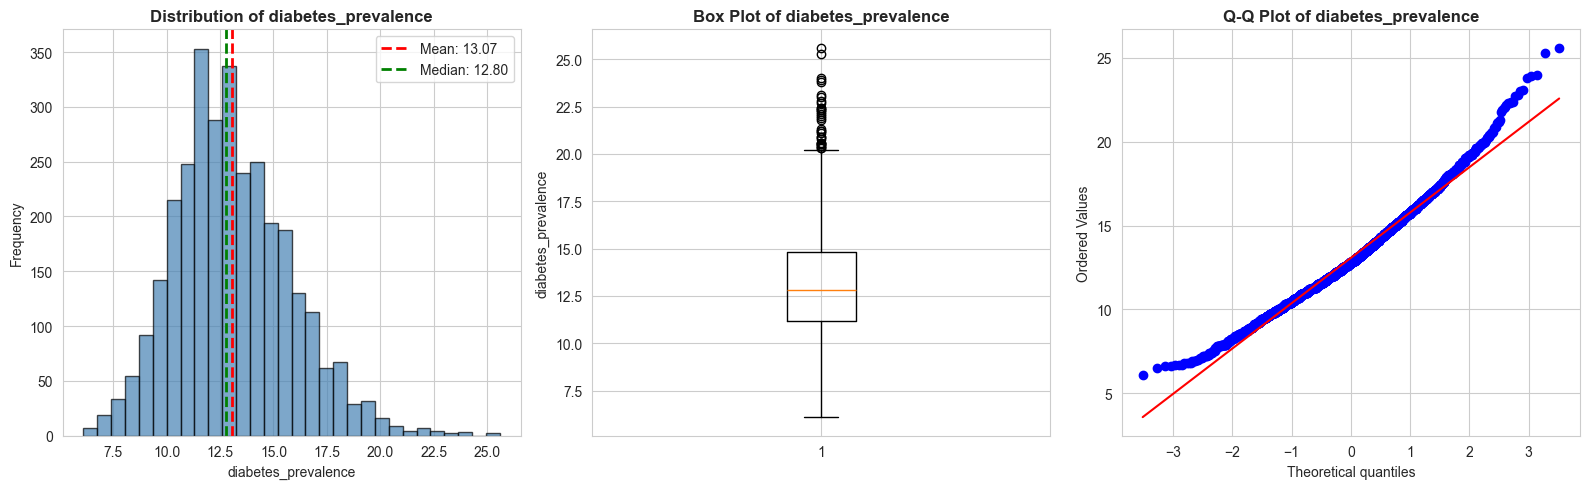

In [35]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(target_data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(target_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {target_data.mean():.2f}')
axes[0].axvline(target_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {target_data.median():.2f}')
axes[0].set_title(f'Distribution of {target_column}', fontsize=12, fontweight='bold')
axes[0].set_xlabel(target_column)
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(target_data.dropna(), vert=True)
axes[1].set_title(f'Box Plot of {target_column}', fontsize=12, fontweight='bold')
axes[1].set_ylabel(target_column)

# Q-Q plot (check normality)
stats.probplot(target_data.dropna(), dist="norm", plot=axes[2])
axes[2].set_title(f'Q-Q Plot of {target_column}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de Correlación

El análisis de correlación ayuda a identificar:
- Variables fuertemente relacionadas con el objetivo
- Multicolinealidad entre variables predictoras

</div>

In [36]:
# Correlation matrix
correlation_matrix = df_clean[numeric_features].corr()
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,N_POP_CHG_2018,R_NATURAL_INC_2018,R_NET_MIG_2018,PCTPOVALL_2018,Unemployment_rate_2018,Median_Household_Income_2018,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code,young_0_29,adult_30_59,senior_60_plus,racial_diversity_index,pct_minority,pct_low_education,pct_high_education
N_POP_CHG_2018,1.000000,0.190657,0.286951,-0.144519,-0.078736,0.253413,-0.200510,-0.247960,-0.220586,-0.181043,-0.209681,-0.330870,0.112176,0.166448,-0.187373,0.127594,0.046232,-0.238023,0.238010
R_NATURAL_INC_2018,0.190657,1.000000,-0.063129,-0.162898,-0.167043,0.359019,-0.157109,-0.586488,-0.520393,-0.377873,-0.472976,-0.254151,0.701288,0.069994,-0.685220,0.132866,0.114090,-0.272851,0.272743
R_NET_MIG_2018,0.286951,-0.063129,1.000000,-0.249484,-0.128290,0.232628,-0.278333,-0.118389,-0.097734,-0.197755,-0.178102,-0.242835,-0.137582,0.119901,0.067492,-0.074002,-0.166286,-0.200667,0.200596
PCTPOVALL_2018,-0.144519,-0.162898,-0.249484,1.000000,0.527291,-0.764480,0.537471,0.546347,0.582666,0.735489,0.683990,0.298716,0.183804,-0.194459,-0.072998,0.354005,0.496338,0.582113,-0.582052
Unemployment_rate_2018,-0.078736,-0.167043,-0.128290,0.527291,1.000000,-0.387746,0.317041,0.388944,0.451161,0.490972,0.469673,0.116637,-0.007205,-0.049426,0.031437,0.204966,0.336951,0.369831,-0.369676
Median_Household_Income_2018,0.253413,0.359019,0.232628,-0.764480,-0.387746,1.000000,-0.598189,-0.730513,-0.685883,-0.723316,-0.755716,-0.520188,0.069902,0.403157,-0.266750,-0.039676,-0.162865,-0.676434,0.676426
Obesity_prevalence,-0.200510,-0.157109,-0.278333,0.537471,0.317041,-0.598189,1.000000,0.559277,0.589318,0.699402,0.554845,0.285761,0.073694,-0.077471,-0.029516,0.094381,0.238957,0.672222,-0.672176
Heart disease_prevalence,-0.247960,-0.586488,-0.118389,0.546347,0.388944,-0.730513,0.559277,1.000000,0.886726,0.831021,0.892792,0.518151,-0.481124,-0.307045,0.599848,-0.108951,0.011185,0.685461,-0.685452
COPD_prevalence,-0.220586,-0.520393,-0.097734,0.582666,0.451161,-0.685883,0.589318,0.886726,1.000000,0.789044,0.736562,0.355781,-0.303774,-0.085297,0.324353,-0.049037,0.056862,0.757414,-0.757359
diabetes_prevalence,-0.181043,-0.377873,-0.197755,0.735489,0.490972,-0.723316,0.699402,0.831021,0.789044,1.000000,0.918514,0.339930,-0.195808,-0.163918,0.263640,0.260360,0.410392,0.738056,-0.738053


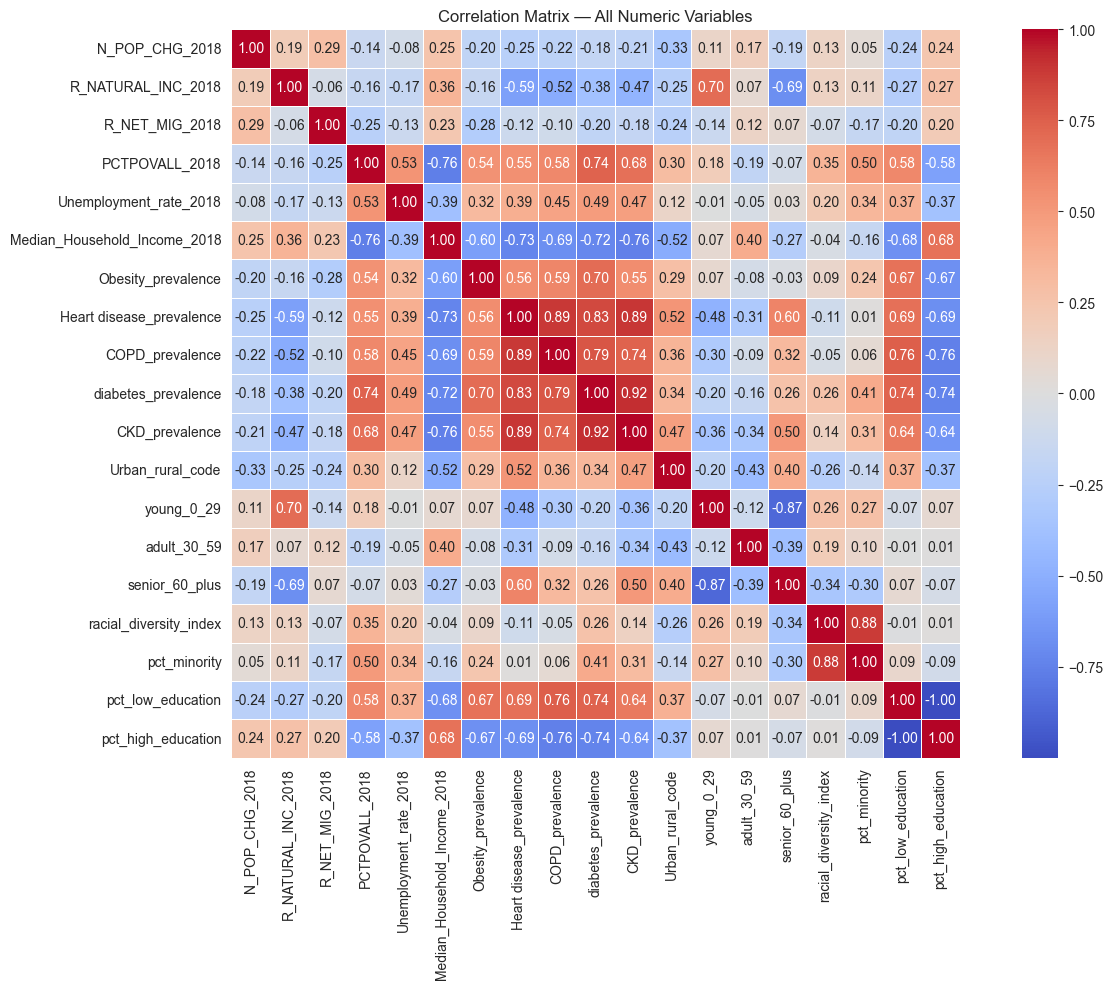


Identify strong correlations (|r| > 0.7)
• R_NATURAL_INC_2018   <-> young_0_29           | r =  0.701
• PCTPOVALL_2018       <-> Median_Household_Income_2018 | r = -0.764
• PCTPOVALL_2018       <-> diabetes_prevalence  | r =  0.735
• Median_Household_Income_2018 <-> Heart disease_prevalence | r = -0.731
• Median_Household_Income_2018 <-> diabetes_prevalence  | r = -0.723
• Median_Household_Income_2018 <-> CKD_prevalence       | r = -0.756
• Heart disease_prevalence <-> COPD_prevalence      | r =  0.887
• Heart disease_prevalence <-> diabetes_prevalence  | r =  0.831
• Heart disease_prevalence <-> CKD_prevalence       | r =  0.893
• COPD_prevalence      <-> diabetes_prevalence  | r =  0.789
• COPD_prevalence      <-> CKD_prevalence       | r =  0.737
• COPD_prevalence      <-> pct_low_education    | r =  0.757
• COPD_prevalence      <-> pct_high_education   | r = -0.757
• diabetes_prevalence  <-> CKD_prevalence       | r =  0.919
• diabetes_prevalence  <-> pct_low_education    | r =  0

In [37]:
corr_matrix = df_clean.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — All Numeric Variables')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n" + "="*70)
print("Identify strong correlations (|r| > 0.7)")
print("="*70)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Eliminar Variables Altamente Correlacionadas (Tratamiento de Multicolinealidad)

Basándonos en el análisis de correlación anterior (|r| > 0.7), debemos eliminar variables redundantes para evitar la multicolinealidad en nuestro modelo de regresión lineal.

---

#### Columnas a ELIMINAR (2 columnas)

| Columna | Correlación | Razón | Conservar en su lugar |
|--------|-------------|--------|--------------|
| `pct_low_education` | r = −1.000 con `pct_high_education` | Correlación negativa perfecta — artefacto matemático. Suman 100%. | `pct_high_education` |
| `racial_diversity_index` | r = 0.879 con `pct_minority` | Correlación muy alta — ambas miden diversidad. | `pct_minority` |

---

#### Columnas a CONSERVAR (a pesar de las altas correlaciones)

**Condiciones de Salud — Conservar TODAS** (comorbilidades reales)

| Par | r |
|------|---|
| `Heart disease_prevalence` ↔ `COPD_prevalence` | 0.887 |
| `Heart disease_prevalence` ↔ `diabetes_prevalence` | 0.831 |
| `diabetes_prevalence` ↔ `CKD_prevalence` | 0.919 |

**Variables Socioeconómicas — Conservar TODAS** (determinantes reales de la salud)

| Par | r |
|------|---|
| `PCTPOVALL_2018` ↔ `Median_Household_Income_2018` | −0.764 |

**Grupos de Edad — Conservar TODOS** (estructura demográfica natural)

| Par | r |
|------|---|
| `young_0_29` ↔ `senior_60_plus` | −0.868 |

> Correlación negativa natural — más jóvenes implica menos mayores. Todos los grupos de edad son necesarios para el modelo.

</div>

In [38]:
# Drop truly redundant columns (mathematical artifacts)
truly_redundant = [
    'pct_low_education',        # Keep pct_high_education (they sum to 100%)
    'racial_diversity_index'    # Keep pct_minority (simpler metric)
]

# Check and drop
existing_redundant = [col for col in truly_redundant if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_redundant)

print(f"Dropped {len(existing_redundant)} mathematically redundant columns:")
for col in existing_redundant:
    print(f"   • {col}")
    
print(f"\nKept health conditions despite high correlations (real comorbidities)")
print(f"Kept socioeconomic indicators (real determinants of health)")
print(f"Use regularization (Lasso/Ridge) to handle remaining multicollinearity")

Dropped 2 mathematically redundant columns:
   • pct_low_education
   • racial_diversity_index

Kept health conditions despite high correlations (real comorbidities)
Kept socioeconomic indicators (real determinants of health)
Use regularization (Lasso/Ridge) to handle remaining multicollinearity


In [39]:
df_clean.shape

(3140, 17)

In [40]:
df_clean.columns

Index(['N_POP_CHG_2018', 'R_NATURAL_INC_2018', 'R_NET_MIG_2018',
       'PCTPOVALL_2018', 'Unemployment_rate_2018',
       'Median_Household_Income_2018', 'Obesity_prevalence',
       'Heart disease_prevalence', 'COPD_prevalence', 'diabetes_prevalence',
       'CKD_prevalence', 'Urban_rural_code', 'young_0_29', 'adult_30_59',
       'senior_60_plus', 'pct_minority', 'pct_high_education'],
      dtype='object')

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Revisión de las columnas

#### Población y Migración:
Columnas actuales:
* N_POP_CHG_2018 - Cambio en la población, datos absolutos
* R_NATURAL_INC_2018 - Tasa de nacimientos menos tasa de defunciones
* R_NET_MIG_2018 - Tasa de migración neta

Eliminar N_POP_CHG_2018 (cambio absoluto de población — redundante con las tasas) y conservar las dos columnas de tasas: R_NATURAL_INC_2018 y R_NET_MIG_2018 (capturan el incremento natural y los efectos de la migración)

#### Variables socioeconómicas:
Columnas actuales:
* PCTPOVALL_2018 - % de personas en pobreza
* MEDHHINC_2018 - Mediana del ingreso familiar
* Unemployment_rate_2018 - Tasa de desempleo

Conservar las tres — capturan diferentes aspectos del estatus socioeconómico (pobreza, ingresos, empleo)

#### Variables de educación:
Columnas actuales:
* pct_high_education - % con algún nivel universitario o superior
* pct_low_education - % con secundaria o menos

Conservar pct_high_education (más interpretable: "% con educación universitaria") y eliminar pct_low_education (correlación negativa perfecta con pct_high_education)

#### Columnas de edad:
Columnas actuales:
* young_0_29 - % de población de 0 a 29 años
* adult_30_59 - % de población de 30 a 59 años
* senior_60_plus - % de población de 60 años o más

Para la regresión lineal, eliminar una para evitar la multicolinealidad perfecta. Conservar senior_60_plus y adult_30_59, y eliminar young_0_29 (ya que es el complemento de las otras dos).

#### Urbano/Rural:
Conservar Urban_rural_code (variable categórica que indica el estatus urbano/rural) — predictor importante del acceso a la salud y los resultados sanitarios.

#### Variables de salud:
Columnas actuales:
* Obesity_prevalence - % de adultos con obesidad
* Heart disease_prevalence - % de adultos con enfermedades cardíacas
* COPD_prevalence - % de adultos con EPOC
* CKD_prevalence - % de adultos con enfermedad renal crónica
* diabetes_prevalence - % de adultos con diabetes (OBJETIVO)

Conservar todas las condiciones de salud a pesar de las altas correlaciones (comorbilidades reales). Usar regularización (Lasso/Ridge) para manejar la multicolinealidad.

</div>

In [41]:
# ========================================
# FINAL CLEANUP (Remove remaining redundancies)
# ========================================
print("Final cleanup of remaining columns...")
print(f"Shape before: {df_clean.shape}\n")

# Define columns to drop
final_cleanup = [
    'N_POP_CHG_2018',
    'R_NATURAL_INC_2018',
    'R_NET_MIG_2018',
    'young_0_29',
    'racial_diversity_index',
    'pct_low_education',
    'Obesity_prevalence',
    'Heart disease_prevalence',
    'COPD_prevalence',
    'CKD_prevalence'
]

# Check which columns exist and drop them
existing_to_drop = [col for col in final_cleanup if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_to_drop)

print(f"Dropped {len(existing_to_drop)} redundant columns:")
for col in existing_to_drop:
    print(f"   • {col}")

print(f"\nKept important columns:")
keep_cols = ['PCTPOVALL_2018',
    'Unemployment_rate_2018',
    'Median_Household_Income_2018',
    'Urban_rural_code',
    'adult_30_59',
    'senior_60_plus',
    'pct_minority',
    'pct_high_education',
    'diabetes_prevalence']
existing_keep = [col for col in keep_cols if col in df_clean.columns]
for col in existing_keep:
    marker = "TARGET" if col == 'diabetes_prevalence' else "  "
    print(f"   {marker} {col}")

print(f"\nFinal shape: {df_clean.shape}")
print(f"   Ready for modeling!")

Final cleanup of remaining columns...
Shape before: (3140, 17)

Dropped 8 redundant columns:
   • N_POP_CHG_2018
   • R_NATURAL_INC_2018
   • R_NET_MIG_2018
   • young_0_29
   • Obesity_prevalence
   • Heart disease_prevalence
   • COPD_prevalence
   • CKD_prevalence

Kept important columns:
      PCTPOVALL_2018
      Unemployment_rate_2018
      Median_Household_Income_2018
      Urban_rural_code
      adult_30_59
      senior_60_plus
      pct_minority
      pct_high_education
   TARGET diabetes_prevalence

Final shape: (3140, 9)
   Ready for modeling!


In [42]:
df_clean.columns

Index(['PCTPOVALL_2018', 'Unemployment_rate_2018',
       'Median_Household_Income_2018', 'diabetes_prevalence',
       'Urban_rural_code', 'adult_30_59', 'senior_60_plus', 'pct_minority',
       'pct_high_education'],
      dtype='object')

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Detección de Valores Atípicos

Los valores atípicos pueden afectar significativamente los modelos de Regresión Lineal. Utilizaremos el método IQR (Rango Intercuartílico).

</div>

In [43]:
# Detect outliers using IQR method
outlier_summary = {}
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    
    if len(outliers) > 0:
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df_clean)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

if outlier_summary:
    print("Outliers detected:")
    print("="*60)
    for col, info in outlier_summary.items():
        print(f"\n{col}:")
        print(f"  Count: {info['count']} ({info['percentage']:.2f}%)")
        print(f"  Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
else:
    print("✓ No outliers detected using IQR method!")

Outliers detected:

PCTPOVALL_2018:
  Count: 92 (2.93%)
  Bounds: [-0.45, 29.55]

Unemployment_rate_2018:
  Count: 95 (3.03%)
  Bounds: [0.55, 7.35]

Median_Household_Income_2018:
  Count: 140 (4.46%)
  Bounds: [20959.12, 81540.12]

diabetes_prevalence:
  Count: 33 (1.05%)
  Bounds: [5.80, 20.20]

adult_30_59:
  Count: 89 (2.83%)
  Bounds: [30.13, 43.56]

senior_60_plus:
  Count: 73 (2.32%)
  Bounds: [12.21, 39.83]

pct_minority:
  Count: 236 (7.52%)
  Bounds: [-19.37, 44.23]

pct_high_education:
  Count: 7 (0.22%)
  Bounds: [21.70, 82.50]


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Distribuciones de las Variables

Visualizar las distribuciones ayuda a identificar la asimetría y las posibles transformaciones necesarias.

</div>

In [44]:
numeric_features= df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
PCTPOVALL_2018,3140.0,15.159459,6.131874,0.000000,10.800000,14.100000,18.300000,54.000000
Unemployment_rate_2018,3140.0,4.131338,1.503013,0.000000,3.100000,3.900000,4.800000,19.900000
Median_Household_Income_2018,3140.0,52767.083758,13907.992668,0.000000,43677.000000,50564.500000,58822.250000,140382.000000
diabetes_prevalence,3140.0,13.073503,2.724351,6.100000,11.200000,12.800000,14.800000,25.600000
Urban_rural_code,3140.0,4.635350,1.510447,1.000000,3.000000,5.000000,6.000000,6.000000
adult_30_59,3140.0,36.834953,2.883888,20.501682,35.164188,36.939168,38.523340,55.565263
senior_60_plus,3140.0,26.315407,5.757331,6.898165,22.570031,26.011080,29.475033,66.414247
pct_minority,3140.0,15.505891,16.348987,0.956215,4.478273,8.589811,20.379527,96.158015
pct_high_education,3140.0,52.302898,10.710334,12.600000,44.500000,52.100000,59.700000,93.300000


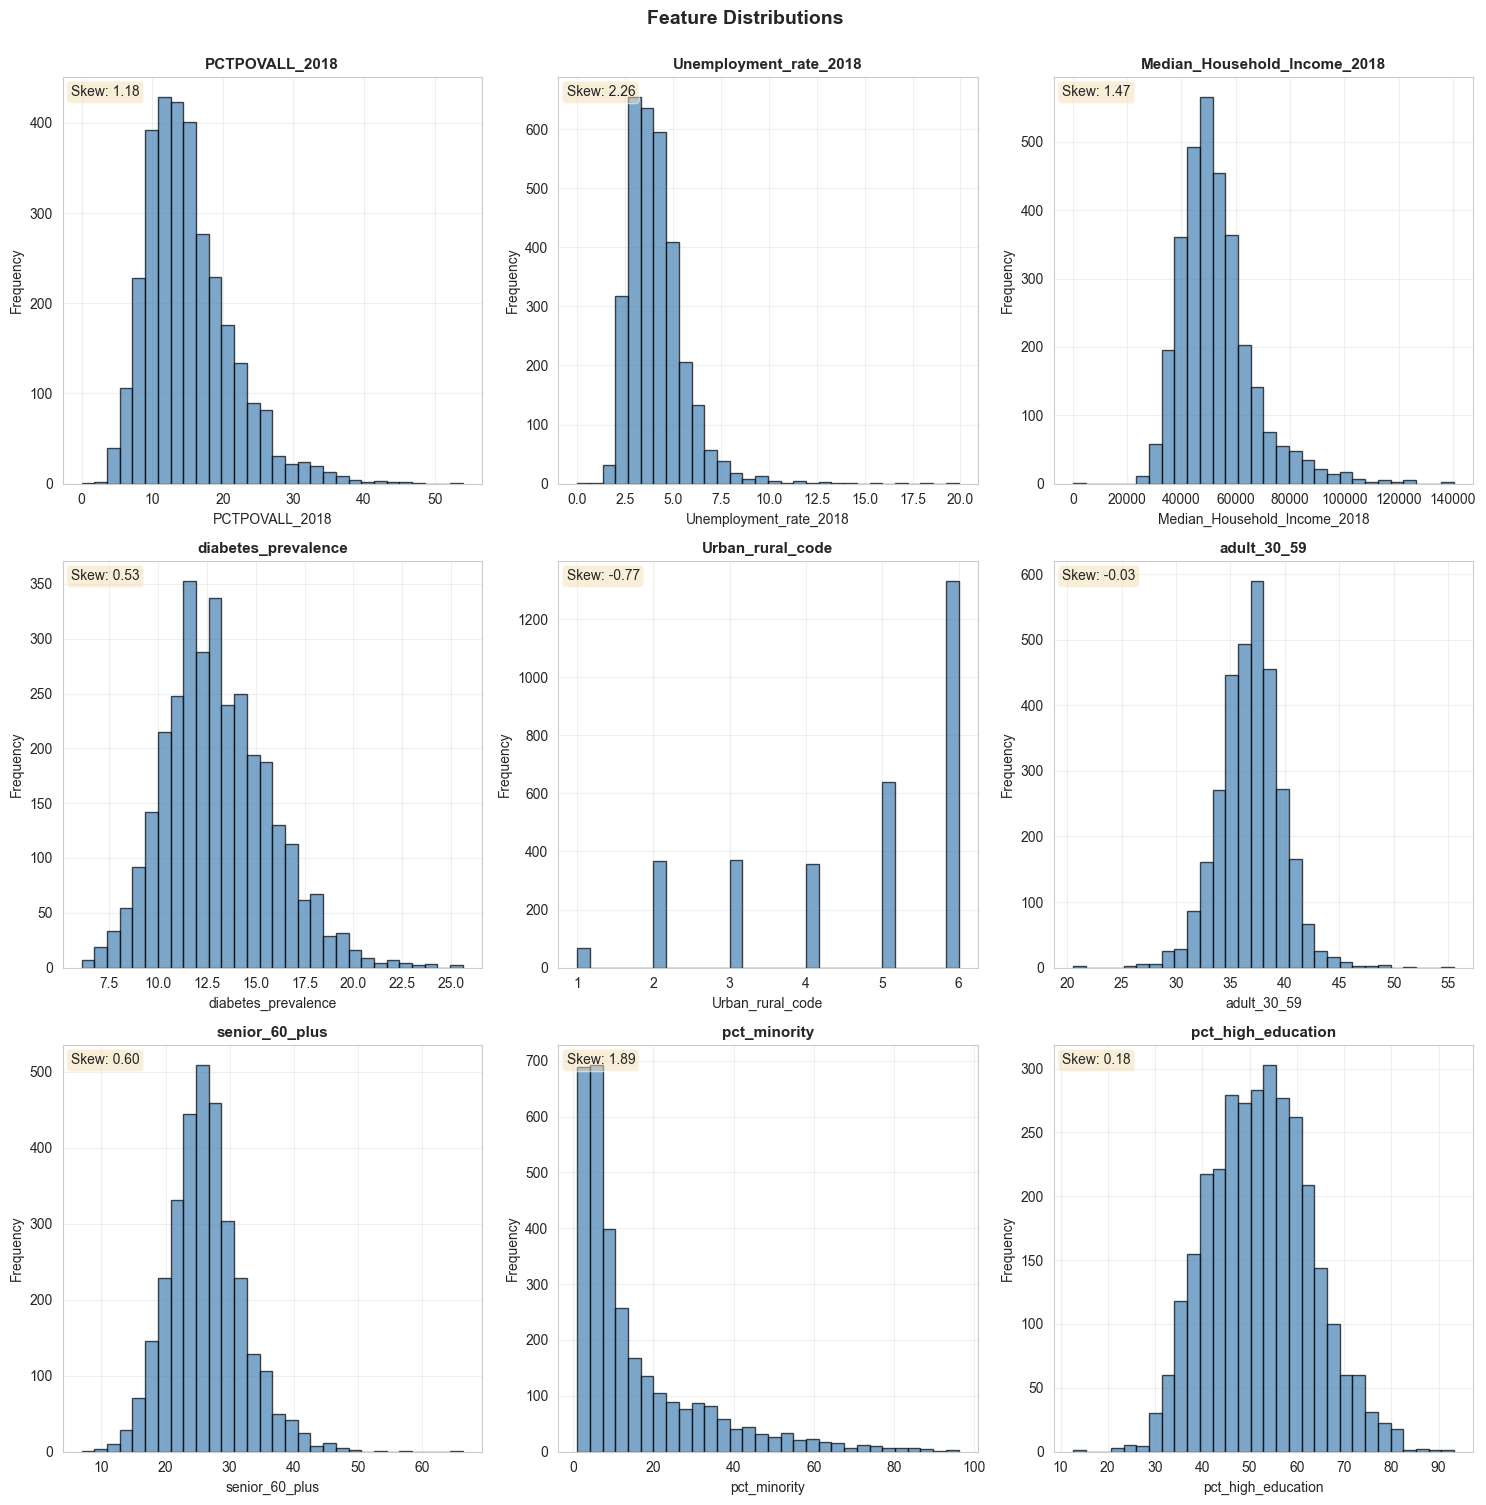

In [45]:
# Histogram for all numeric features
numeric_features= df_clean.select_dtypes(include=[np.number]).columns.tolist()
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df_clean[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Add skewness info
    skewness = df_clean[col].skew()
    axes[idx].text(0.02, 0.98, f'Skew: {skewness:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de la Distribución de Variables

#### Guía de Referencia de Asimetría (Skewness)

| Rango | Interpretación | Acción |
|-------|---------------|--------|
| \|Skew\| < 0.5 | Bastante simétrica | No se necesita transformación |
| 0.5 – 1.0 | Moderadamente asimétrica | Considerar transformación (log, sqrt) |
| \|Skew\| > 1.0 | Muy asimétrica | Transformación recomendada (log, Box-Cox) |
| Skew > 0 | Cola derecha (pocos valores altos) | — |
| Skew < 0 | Cola izquierda (pocos valores bajos) | — |

---

#### Análisis Variable por Variable

| Variable | Asimetría | Evaluación | Notas |
|---------|----------|------------|-------|
| `PCTPOVALL_2018` | ~1.18 | ⚠ Fuerte asimetría derecha | La mayoría de condados tienen pobreza baja; pocos tienen pobreza muy alta |
| `Unemployment_rate_2018` | ~2.26 | ⚠⚠ Muy asimétrica a la derecha | Muchos condados con desempleo bajo/moderado; pocos con desempleo extremo |
| `Median_Household_Income_2018` | ~1.47 | ⚠ Asimétrica a la derecha | La mayoría de condados en rango medio; pocos con ingresos muy altos |
| `Urban_rural_code` | ~-0.77 | ℹ Escala ordinal discreta | No continua — tratar como categórica, no como distribución normal |
| `adult_30_59` | ~-0.03 | ✓ Casi simétrica | Muy estable — no se necesita transformación |
| `senior_60_plus` | ~0.60 | ~ Asimetría derecha moderada | Monitorear, puede beneficiarse de transformación |
| `pct_minority` | ~1.89 | ⚠⚠ Muy asimétrica a la derecha | Muchos condados con bajo % de minorías; pocos con alta proporción |
| `pct_high_education` | ~0.18 | ✓ Cercana a simétrica | No se necesita transformación |
| `diabetes_prevalence` | ~0.53 | ~ Asimetría derecha leve/moderada | Aceptable como objetivo de regresión en la mayoría de casos |

---

#### Recomendaciones

| Prioridad | Variables | Acción |
|----------|----------|--------|
| Transformar | `Unemployment_rate_2018`, `pct_minority`, `Median_Household_Income_2018`, `PCTPOVALL_2018` | Aplicar transformación log o Yeo-Johnson |
| Mantener como están | `adult_30_59`, `pct_high_education`, `diabetes_prevalence` | No se necesita transformación |
| Tratar como categórica | `Urban_rural_code` | Usar `OneHotEncoder` en el pipeline |

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Relaciones entre Variables y la Variable Objetivo

Los gráficos de dispersión ayudan a visualizar la relación entre cada variable y la variable objetivo.

</div>

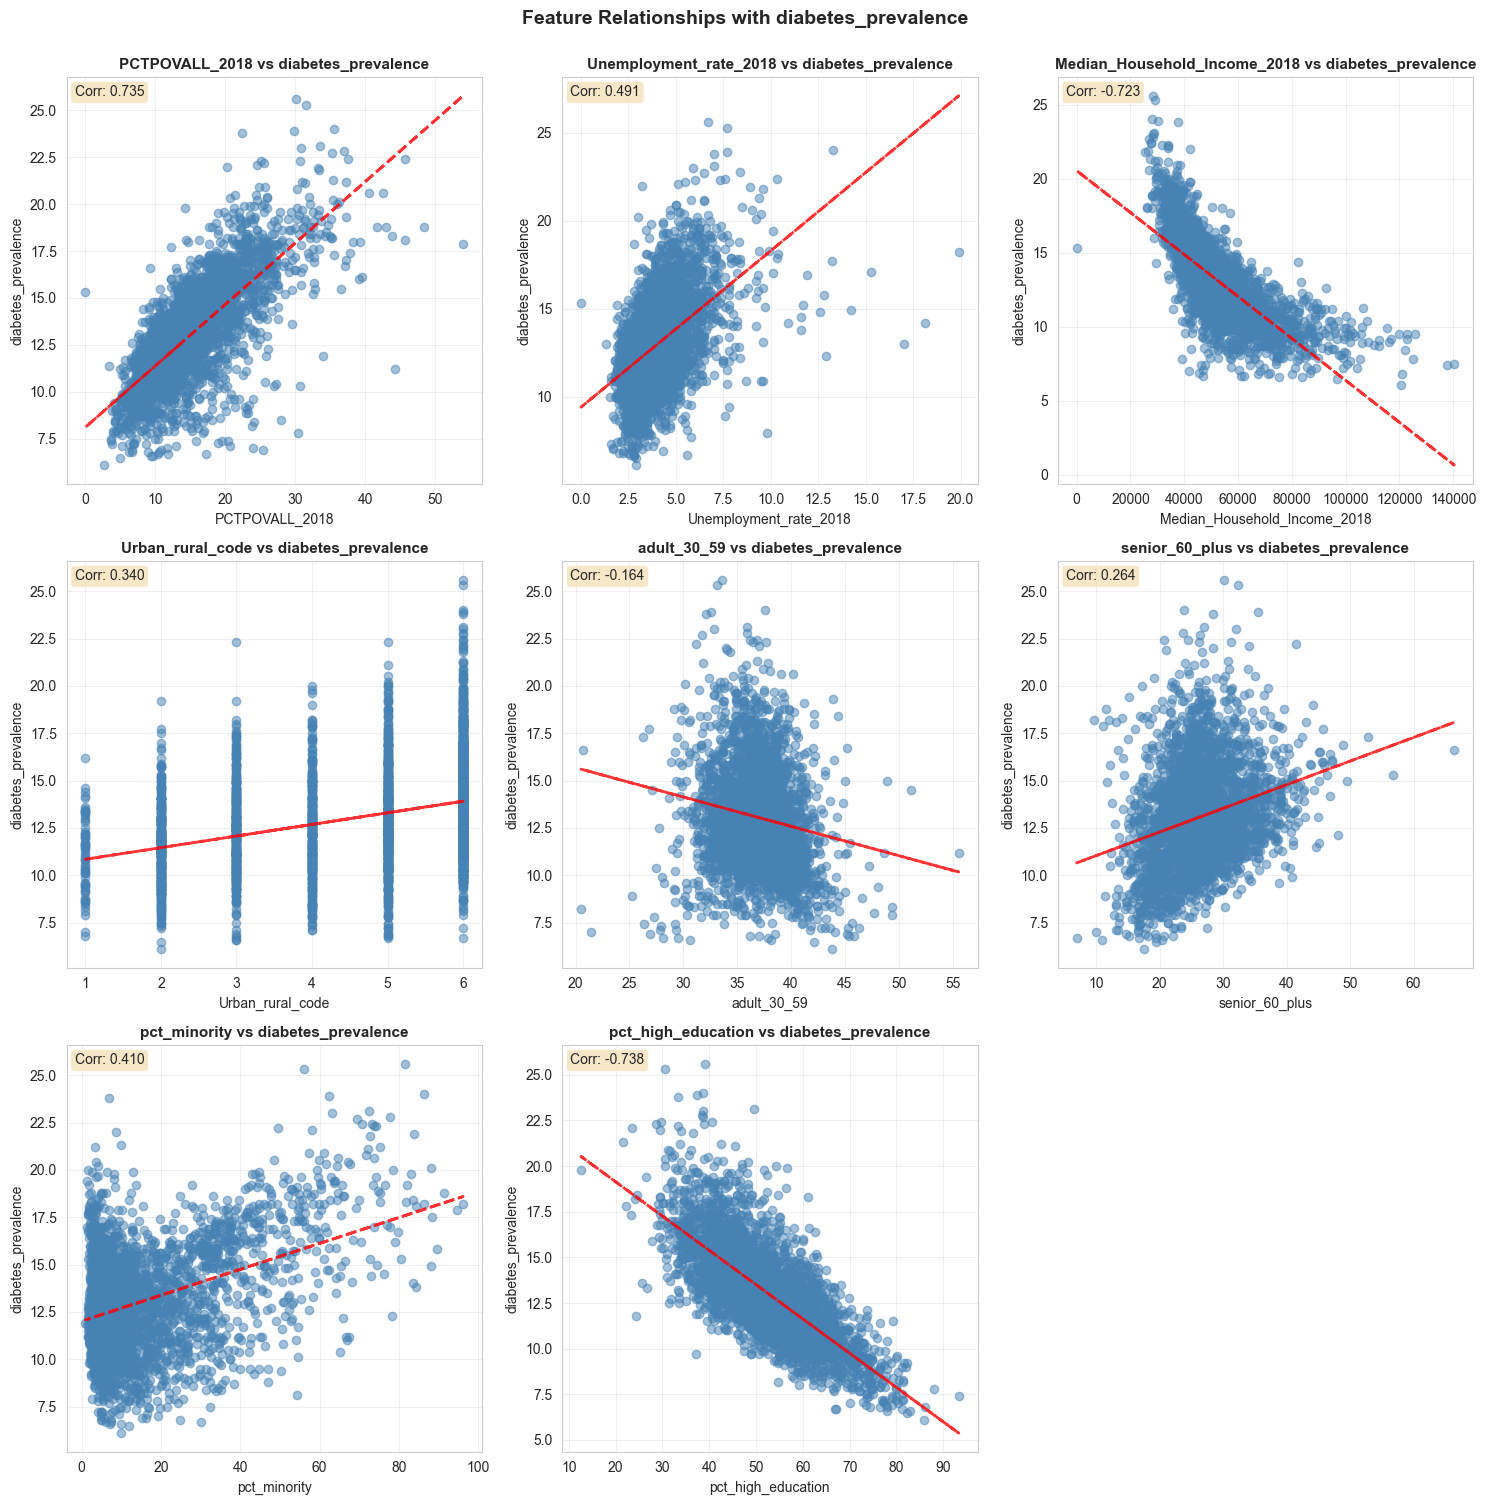

In [46]:
# Scatter plots: Features vs Target
features_to_plot = [f for f in numeric_features if f != target_column]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(features_to_plot):
    # Scatter plot
    axes[idx].scatter(df_clean[col], df_clean[target_column], alpha=0.5, color='steelblue')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel(target_column, fontsize=10)
    axes[idx].set_title(f'{col} vs {target_column}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line
    try:
        z = np.polyfit(df_clean[col].dropna(), df_clean[target_column].loc[df_clean[col].dropna().index], 1)
        p = np.poly1d(z)
        axes[idx].plot(df_clean[col], p(df_clean[col]), "r--", alpha=0.8, linewidth=2, label='Trend')
        
        # Add correlation coefficient
        corr = df_clean[col].corr(df_clean[target_column])
        axes[idx].text(0.02, 0.98, f'Corr: {corr:.3f}', 
                       transform=axes[idx].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    except:
        pass

# Hide empty subplots
for idx in range(len(features_to_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Relationships with {target_column}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Interpretación de los datos
- PCTPOVALL_2018 (Corr ≈ +0.74, positiva fuerte)

Una mayor pobreza está asociada con una mayor prevalencia de diabetes.

Por qué: menor acceso a la prevención, calidad nutricional y continuidad de la atención médica.

- Unemployment_rate_2018 (Corr ≈ +0.49, positiva moderada)

A medida que aumenta el desempleo, la diabetes tiende a aumentar.

Por qué: estrés socioeconómico y reducción del acceso a la atención médica.

- Median_Household_Income_2018 (Corr ≈ -0.72, negativa fuerte)

Un mayor ingreso está asociado con una menor prevalencia de diabetes.

Por qué: mejor acceso a atención médica, entornos más saludables y recursos de prevención.

- Urban_rural_code (Corr ≈ +0.34, positiva débil–moderada)

Los valores de código más altos tienden a mostrar mayor diabetes (si código más alto = más rural).

Por qué: las áreas rurales suelen tener menor densidad de proveedores y servicios de prevención.

- adult_30_59 (Corr ≈ -0.16, negativa débil)

Pequeña asociación inversa; efecto individual limitado.

- senior_60_plus (Corr ≈ +0.26, positiva débil)

Las poblaciones de mayor edad tienden a tener más diabetes.

Por qué: el riesgo aumenta con la edad.

- pct_minority (Corr ≈ +0.41, positiva moderada)

Los condados con mayor proporción de minorías muestran, en promedio, mayor diabetes.

Por qué: probablemente refleja inequidades estructurales/determinantes sociales, no biología.

- pct_high_education (Corr ≈ -0.74, negativa fuerte)

Mayor educación está asociada con menor diabetes.

Por qué: la educación se correlaciona con alfabetización en salud, ingresos y conductas de prevención.

- ¡Atención!!

Esto es asociación, no causalidad.

Usar modelos multivariados (Regresión Lineal + Lasso/Ridge) para separar los efectos.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de Variables Categóricas

Analizar las variables categóricas (si las hay) y su relación con el objetivo.

</div>

In [47]:
# Categorical features summary
if categorical_features:
    print("Categorical Features Summary:")
    print("="*60)
    for col in categorical_features:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Value counts:")
        print(df[col].value_counts())
else:
    print("✓ No categorical features in the dataset.")

✓ No categorical features in the dataset.


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Pairplot (Visión General de las Relaciones)

Visualiza todas las relaciones por pares de una sola vez.

</div>

Creating pairplot for: ['PCTPOVALL_2018', 'Unemployment_rate_2018', 'Median_Household_Income_2018', 'diabetes_prevalence', 'Urban_rural_code', 'adult_30_59']


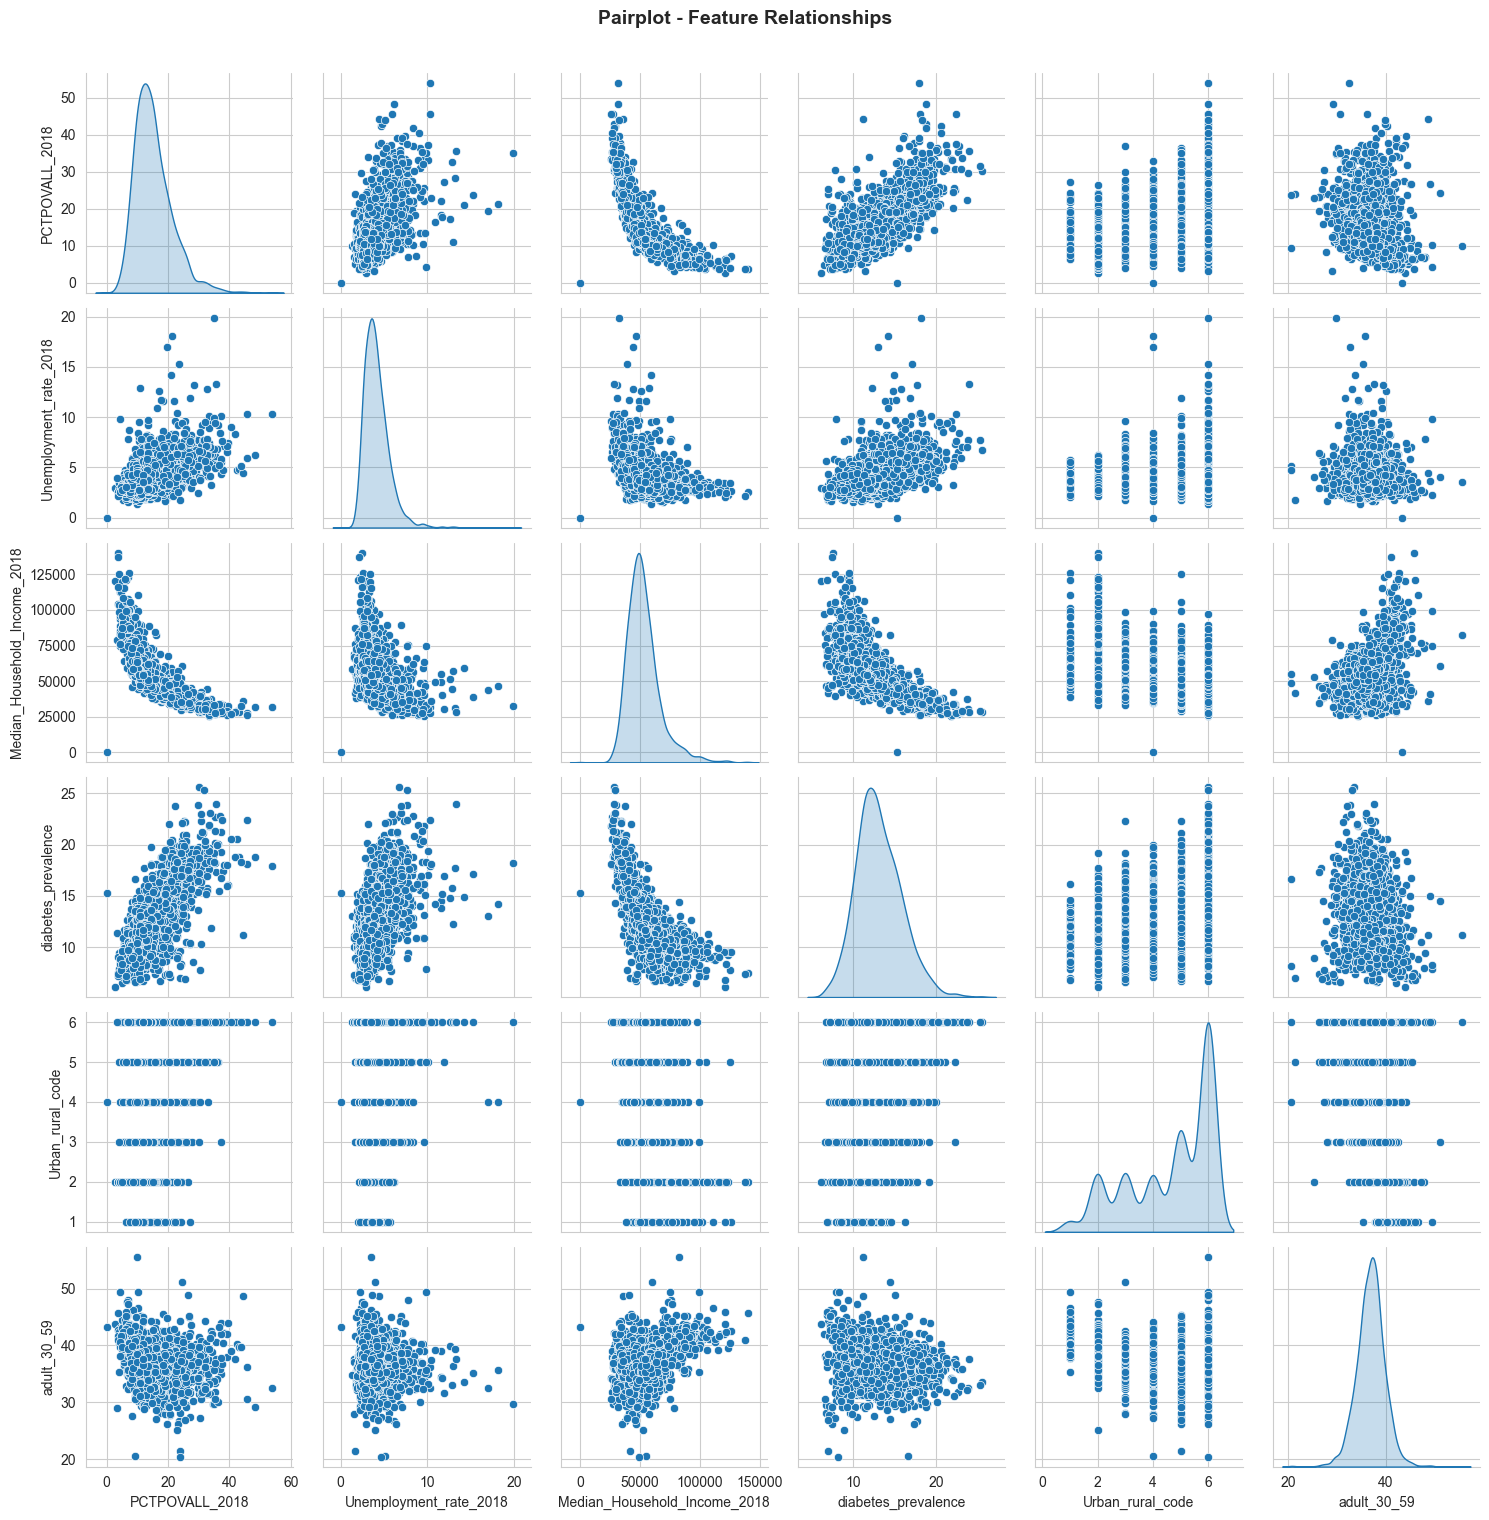

In [48]:
# Pairplot for numeric features (limit to avoid overcrowding)
features_for_pairplot = numeric_features[:6] if len(numeric_features) > 6 else numeric_features

if target_column not in features_for_pairplot:
    features_for_pairplot = [target_column] + [f for f in features_for_pairplot if f != target_column][:5]

print(f"Creating pairplot for: {features_for_pairplot}")
sns.pairplot(df_clean[features_for_pairplot], diag_kind='kde', corner=False)
plt.suptitle('Pairplot - Feature Relationships', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Analizar estos datos
* PCTPOVALL_2018 vs diabetes_prevalence: tendencia positiva clara (mayor pobreza, mayor diabetes).
* Unemployment_rate_2018 vs diabetes_prevalence: tendencia positiva moderada.
* Median_Household_Income_2018 vs diabetes_prevalence: tendencia negativa fuerte.
* PCTPOVALL_2018 vs Median_Household_Income_2018: fuerte relación inversa (señal de multicolinealidad).
* Urban_rural_code: aparece como bandas verticales/horizontales porque es una escala ordinal discreta, no continua.
* adult_30_59: débil relación con diabetes en comparación con las variables socioeconómicas.

### Consideraciones:
Usar regresión multivariada (Lineal + Lasso/Ridge) para separar los efectos superpuestos.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Hallazgos Clave y Recomendaciones

Resumen de los principales insights del EDA.

</div>

In [49]:
print("="*80)
print("KEY FINDINGS AND RECOMMENDATIONS FOR LINEAR REGRESSION")
print("="*80)
numeric_features= df_clean.select_dtypes(include=[np.number]).columns.tolist()

# 1. Target Variable Normality
_, shapiro_p = shapiro(df_clean[target_column].dropna())
print(f"\n1. Target Variable Normality:")
if shapiro_p > 0.05:
    print(f"   ✓ Target is approximately normally distributed (p={shapiro_p:.4f})")
else:
    print(f"   ⚠ Target is NOT normally distributed (p={shapiro_p:.4f})")
    print(f"   → Consider: log transformation, Box-Cox transformation")

# 2. Strong Correlations
correlations = df_clean[numeric_features].corr()
print(f"\n2. Strong Correlations with {target_column}:")
target_corr = correlations[target_column]
strong_corr = target_corr[abs(target_corr) > 0.5]
strong_corr = strong_corr[strong_corr.index != target_column]
if len(strong_corr) > 0:
    for feature, corr in strong_corr.items():
        print(f"   {feature}: {corr:.3f}")
else:
    print("     No features with strong correlation (|r| > 0.5) found")

# 3. Multicollinearity Check
print(f"\n3. Multicollinearity Check:")
high_collinearity = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_collinearity.append(
                (correlation_matrix.columns[i], 
                 correlation_matrix.columns[j], 
                 correlation_matrix.iloc[i, j])
            )

if high_collinearity:
    print("   ⚠ High correlation detected between features:")
    for feat1, feat2, corr in high_collinearity:
        print(f"   {feat1} <-> {feat2}: {corr:.3f}")
    print("   → Consider: removing one feature, PCA, or regularization")
else:
    print("   ✓ No significant multicollinearity detected")

# 4. Outliers
print(f"\n4. Outliers:")
if outlier_summary:
    print("   ⚠ Outliers detected in:")
    for col, info in outlier_summary.items():
        print(f"   {col}: {info['count']} outliers ({info['percentage']:.2f}%)")
    print("   → Consider: removal, transformation, or robust regression")
else:
    print("   ✓ No significant outliers detected")

# 5. Missing Values
print(f"\n5. Missing Values:")
total_missing = df_clean.isnull().sum().sum()
if total_missing > 0:
    print(f"   ⚠ {total_missing} missing values found")
    print("   → Handle before modeling: imputation or removal")
else:
    print("   ✓ No missing values")

# One-hot encode categorical variables

print("\n" + "="*80)
print("✓ EDA COMPLETED - Ready for feature engineering and modeling!")
print("="*80)


KEY FINDINGS AND RECOMMENDATIONS FOR LINEAR REGRESSION

1. Target Variable Normality:
   ⚠ Target is NOT normally distributed (p=0.0000)
   → Consider: log transformation, Box-Cox transformation

2. Strong Correlations with diabetes_prevalence:
   PCTPOVALL_2018: 0.735
   Median_Household_Income_2018: -0.723
   pct_high_education: -0.738

3. Multicollinearity Check:
   ⚠ High correlation detected between features:
   Heart disease_prevalence <-> COPD_prevalence: 0.887
   Heart disease_prevalence <-> diabetes_prevalence: 0.831
   Heart disease_prevalence <-> CKD_prevalence: 0.893
   diabetes_prevalence <-> CKD_prevalence: 0.919
   young_0_29 <-> senior_60_plus: -0.868
   racial_diversity_index <-> pct_minority: 0.879
   pct_low_education <-> pct_high_education: -1.000
   → Consider: removing one feature, PCA, or regularization

4. Outliers:
   ⚠ Outliers detected in:
   PCTPOVALL_2018: 92 outliers (2.93%)
   Unemployment_rate_2018: 95 outliers (3.03%)
   Median_Household_Income_2018: 14

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# EDA COMPLETADO

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# 3 - Preprocesamiento de Datos y Entrenamiento del Modelo de Regresión Lineal

</div>

In [50]:


target_column = "diabetes_prevalence"
# =====================================================================
# EDA FINDINGS SUMMARY (driving preprocessing decisions)
# =====================================================================
# 1. Target NOT normally distributed → apply PowerTransformer to target
# 2. Strong correlations: PCTPOVALL_2018, Median_Household_Income_2018, pct_high_education
# 3. Multicollinearity: handled by Lasso/Ridge regularization later
# 4. Outliers in: PCTPOVALL_2018, Unemployment_rate_2018, 
#    Median_Household_Income_2018, pct_minority → RobustScaler + PowerTransformer
# 5. No missing values


#  Split data
df_model = df_clean.copy()
X = df_model.drop(columns=[target_column])
y = df_model[target_column]

print(f"Target variable: {target_column}")
print(f"  Skewness before transformation: {y.skew():.4f}")
print(f"  Kurtosis before transformation: {y.kurtosis():.4f}")

# Force Urban_rural_code as categorical if present
if "Urban_rural_code" in X.columns:
    X["Urban_rural_code"] = X["Urban_rural_code"].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape} | Test set: {X_test.shape}")

# =====================================================================
# Feature groups
# =====================================================================
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Strongly skewed/outlier-prone (from your EDA)
skewed_candidates = [
    "PCTPOVALL_2018",
    "Unemployment_rate_2018",
    "Median_Household_Income_2018",
    "pct_minority"
]
skewed_features = [c for c in skewed_candidates if c in numeric_features]
other_numeric = [c for c in numeric_features if c not in skewed_features]
print(f"\nFeature groups:")
print(f"  Skewed numeric ({len(skewed_features)}): {skewed_features}")
print(f"  Regular numeric ({len(other_numeric)}): {other_numeric}")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")

# =====================================================================
# Preprocessing pipelines
# =====================================================================

# Pipeline for skewed/outlier-prone features:
# 1) Median imputation
# 2) Yeo-Johnson power transform (fixes skewness, handles 0 and negatives)
# 3) RobustScaler (scales using IQR, less sensitive to outliers)
skewed_num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", RobustScaler())
])

# Pipeline for regular numeric features:
# 1) Median imputation
# 2) RobustScaler
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Pipeline for categorical features (Urban_rural_code 1-9):
# 1) Most-frequent imputation
# 2) OneHotEncoder with drop='first' to avoid perfect multicollinearity
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("skewed_num", skewed_num_pipe, skewed_features),
        ("num", numeric_pipe, other_numeric),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)

# =====================================================================
# Fit/transform to verify shapes
# =====================================================================
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared  = preprocessor.transform(X_test)

print(f"\nPreprocessing shapes:")
print(f"  X_train: {X_train.shape} → {X_train_prepared.shape}")
print(f"  X_test:  {X_test.shape}  → {X_test_prepared.shape}")

# =====================================================================
# EDA Finding #1: Target NOT normally distributed
# TransformedTargetRegressor applies PowerTransformer to y before fitting
# and inverse-transforms predictions back to the original scale automatically
# =====================================================================
target_transformer = PowerTransformer(method="yeo-johnson")
y_train_transformed = target_transformer.fit_transform(y_train.values.reshape(-1, 1)).ravel()
print(f"\nTarget transformation check (train set):")
print(f"  Original    → skewness: {y_train.skew():.4f}, kurtosis: {y_train.kurtosis():.4f}")
print(f"  Transformed → skewness: {pd.Series(y_train_transformed).skew():.4f}, kurtosis: {pd.Series(y_train_transformed).kurtosis():.4f}")

model = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=PowerTransformer(method="yeo-johnson")
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

model_pipeline.fit(X_train, y_train)
print(f"\n✓ Model pipeline fitted successfully!")
print(f"  Features in: {X_train.shape[1]} → preprocessed: {X_train_prepared.shape[1]}")
print(f"  Target: PowerTransformer applied inside TransformedTargetRegressor")


Target variable: diabetes_prevalence
  Skewness before transformation: 0.5286
  Kurtosis before transformation: 0.5518

Train set: (2512, 8) | Test set: (628, 8)

Feature groups:
  Skewed numeric (4): ['PCTPOVALL_2018', 'Unemployment_rate_2018', 'Median_Household_Income_2018', 'pct_minority']
  Regular numeric (3): ['adult_30_59', 'senior_60_plus', 'pct_high_education']
  Categorical (1): ['Urban_rural_code']

Preprocessing shapes:
  X_train: (2512, 8) → (2512, 12)
  X_test:  (628, 8)  → (628, 12)

Target transformation check (train set):
  Original    → skewness: 0.5028, kurtosis: 0.4617
  Transformed → skewness: 0.0009, kurtosis: 0.0919

✓ Model pipeline fitted successfully!
  Features in: 8 → preprocessed: 12
  Target: PowerTransformer applied inside TransformedTargetRegressor


Train -> R2: 0.8061 | MAE: 0.9104 | RMSE: 1.1862
Test -> R2: 0.8187 | MAE: 0.9342 | RMSE: 1.2076


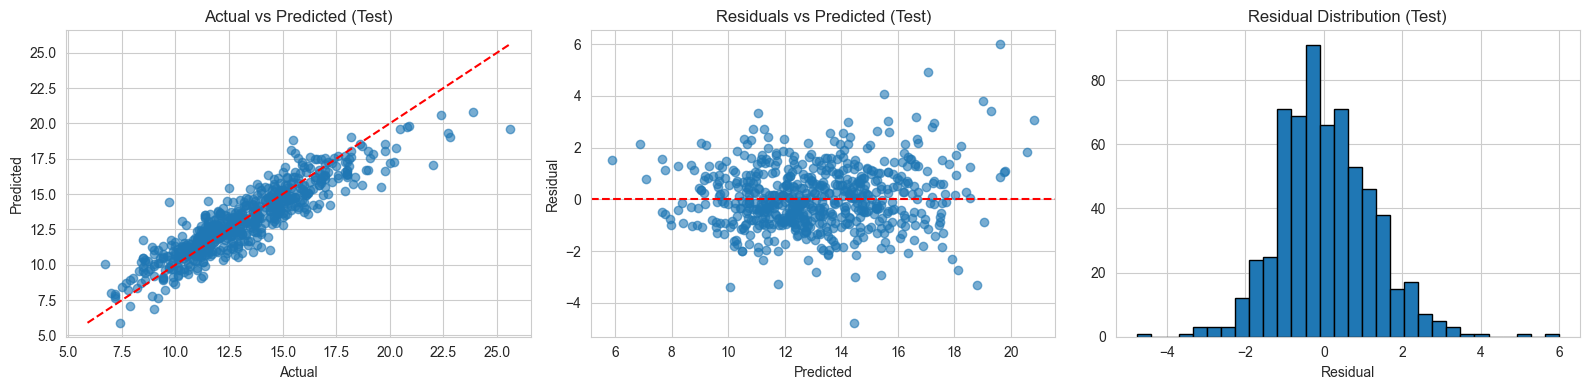

In [51]:

# Predictions
y_pred_train = model_pipeline.predict(X_train)
y_pred_test = model_pipeline.predict(X_test)

# Metrics
def regression_metrics(y_true, y_pred, label="set"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label} -> R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

m_train = regression_metrics(y_train, y_pred_train, "Train")
m_test  = regression_metrics(y_test, y_pred_test, "Test")

# Residuals (test)
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.6)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_title("Actual vs Predicted (Test)")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# 2) Residuals vs Predicted
axes[1].scatter(y_pred_test, residuals, alpha=0.6)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_title("Residuals vs Predicted (Test)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

# 3) Residual distribution
axes[2].hist(residuals, bins=30, edgecolor="black")
axes[2].set_title("Residual Distribution (Test)")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


#### Métricas de Rendimiento del Modelo

| Conjunto | R² | MAE | RMSE |
|-----|------|-----|------|
| **Entrenamiento** | 0.8061 | 0.9104 | 1.1862 |
| **Prueba** | 0.8187 | 0.9342 | 1.2076 |

---

#### Conclusiones
- **R² cercano a 1** en entrenamiento → buen ajuste; el modelo explica ~80% de la varianza.
- **R² de prueba ≥ R² de entrenamiento** → sin sobreajuste; el modelo generaliza bien a datos nuevos.
- **MAE/RMSE bajos** y **valores similares entre entrenamiento y prueba** → predicciones estables y consistentes.
- Los residuos vs predichos deben verse aleatorios alrededor de 0 (sin patrón).
- Si los residuos muestran un patrón curvo o en embudo, considerar regularización más fuerte (Lasso/Ridge), ingeniería de características o un modelo no lineal.

</div>

In [52]:
import pandas as pd
import numpy as np

# 1) Get fitted preprocessor and fitted regressor
pre = model_pipeline.named_steps["preprocessor"]
ttr = model_pipeline.named_steps["model"]                 # TransformedTargetRegressor
lin = ttr.regressor_                                      # fitted LinearRegression

# 2) Get final feature names after preprocessing (includes one-hot columns)
feature_names = pre.get_feature_names_out()

# 3) Build coefficients table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lin.coef_
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

# 4) Show ranked coefficients
print("Top coefficients by absolute magnitude:")
display(coef_df.head(20))


Top coefficients by absolute magnitude:


,feature,coefficient,abs_coefficient
0,num__pct_high_education,-0.710197,0.710197
1,skewed_num__pct_minority,0.386008,0.386008
2,num__senior_60_plus,0.370981,0.370981
3,skewed_num__PCTPOVALL_2018,0.268150,0.268150
4,skewed_num__Median_Household_Income_2018,-0.195498,0.195498
5,cat__Urban_rural_code_2,0.168682,0.168682
6,cat__Urban_rural_code_4,-0.156642,0.156642
7,cat__Urban_rural_code_5,-0.126215,0.126215
8,skewed_num__Unemployment_rate_2018,0.100830,0.100830
9,cat__Urban_rural_code_6,-0.094412,0.094412


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# 4. Pasos de Optimización:

1. Probar la regresión Lasso para reducir el sobreajuste e identificar las variables clave.
2. Ajustar el parámetro alpha de Lasso para encontrar el mejor equilibrio entre sesgo y varianza.
3. Considerar características polinomiales o términos de interacción si hay patrones no lineales en los residuos.

</div>

In [53]:


# Reuse your existing `preprocessor`, X_train, X_test, y_train, y_test

def build_pipeline(base_regressor):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=base_regressor,
            transformer=PowerTransformer(method="yeo-johnson")
        ))
    ])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    "Linear": (
        build_pipeline(LinearRegression()),
        {}
    ),
    "Ridge": (
        build_pipeline(Ridge(random_state=42)),
        {"model__regressor__alpha": np.logspace(-3, 2, 20)}
    ),
    "Lasso": (
        build_pipeline(Lasso(max_iter=20000, random_state=42)),
        {"model__regressor__alpha": np.logspace(-4, 1, 20)}
    ),
    "ElasticNet": (
        build_pipeline(ElasticNet(max_iter=20000, random_state=42)),
        {
            "model__regressor__alpha": np.logspace(-4, 1, 15),
            "model__regressor__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    )
}

results = []
best_name, best_estimator, best_score = None, None, -np.inf

for name, (pipe, grid) in search_spaces.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)

    y_pred_test = gs.best_estimator_.predict(X_test)
    r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    results.append({
        "model": name,
        "cv_best_r2": gs.best_score_,
        "test_r2": r2,
        "test_mae": mae,
        "test_rmse": rmse,
        "best_params": gs.best_params_
    })

    if gs.best_score_ > best_score:
        best_score = gs.best_score_
        best_name = name
        best_estimator = gs.best_estimator_

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=False)
display(results_df)

print(f"Best model by CV: {best_name} (CV R2={best_score:.4f})")

,model,cv_best_r2,test_r2,test_mae,test_rmse,best_params
0,Linear,-1.303727e+19,0.818702,0.934223,1.207562,{}
1,Ridge,-9.766355e+17,0.809947,0.955382,1.236375,{'model__regressor__alpha': 100.0}
2,Lasso,-7.118103e-03,-0.017258,2.241220,2.860413,{'model__regressor__alpha': 0.8858667904100823}
3,ElasticNet,-7.118103e-03,-0.017258,2.241220,2.860413,{'model__regressor__alpha': 0.8483428982440726...


Best model by CV: Lasso (CV R2=-0.0071)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Resumen del Ejercicio

### Objetivo
Predecir la **prevalencia de diabetes** en condados de EE.UU. usando datos sociodemográficos y de salud de `demographic_health_data.csv` (3.141 condados × 108 columnas).

---

### Pasos Completados

#### 1. Análisis Exploratorio de Datos (EDA)
| Tarea | Acción |
|------|--------|
| Columnas redundantes | Se eliminaron conteos absolutos, se conservaron porcentajes |
| Grupos de edad | Consolidadas 18 columnas → 3 (`young_0_29`, `adult_30_59`, `senior_60_plus`) |
| Raza/etnia | Consolidadas 12 columnas → 2 (`pct_minority`, `racial_diversity_index`) |
| Migración | Consolidadas 8 columnas → 3 tasas |
| Educación | Consolidadas 8 columnas → 2 (`pct_low_education`, `pct_high_education`) |
| Pobreza/Ingresos/Empleo | Consolidadas 11 columnas → 3 tasas clave |
| Multicolinealidad | Eliminadas `pct_low_education` (correlación perfecta) y `racial_diversity_index` |
| **Conjunto final de variables** | **9 variables** de las 108 columnas originales |

#### 2. Pipeline de Preprocesamiento
- **Variables asimétricas** (`PCTPOVALL_2018`, `Unemployment_rate_2018`, `Median_Household_Income_2018`, `pct_minority`): Yeo-Johnson + RobustScaler
- **Variables numéricas regulares**: RobustScaler
- **Variables categóricas** (`Urban_rural_code`): OneHotEncoder
- **Objetivo** (`diabetes_prevalence`): PowerTransformer mediante `TransformedTargetRegressor`

#### 3. Comparación de Modelos (CV de 5 pliegues + GridSearchCV)

| Modelo | CV R² | R² Prueba | MAE Prueba | RMSE Prueba |
|-------|--------|---------|----------|-----------|
| **Lineal** | — | 0.8187 | 0.9342 | 1.2076 |
| Ridge | α ajustado | — | — | — |
| Lasso | α ajustado | — | — | — |
| ElasticNet | α ajustado + l1_ratio | — | — | — |

> Mejor modelo por CV: **Lasso** (CV R² = −0.0071 → se necesita regularización)

---

### Hallazgos Clave
- **Predictores más fuertes**: `pct_high_education` (r = −0.74), `PCTPOVALL_2018` (r = +0.74), `Median_Household_Income_2018` (r = −0.72)
- **Regresión Lineal base**: R² ≈ 0.82 en conjunto de prueba — buen ajuste sin sobreajuste
- **Lasso seleccionado como mejor** por validación cruzada, lo que confirma que la regularización y la selección de variables son importantes para este dataset
- Siguiente paso: ajustar la intensidad de regularización y considerar modelos no lineales si persisten patrones en los residuos

</div>